# Taller 1 · Del voltaje crudo a la figura

**De la neurona a la figura** · Análisis neuronal en insectos asistido por IA

| | |
|---|---|
| **Cuándo se trabaja** | martes 18 (2 h) y jueves 20 de agosto de 2026 (1 h) |
| **Entrega** | martes 25 de agosto de 2026, completo |
| **Modalidad** | en parejas · versionado en GitHub |
| **Valor** | 15 % de la nota final |
| **Datos** | registro extracelular sintético de **un electrodo**, generado para este curso |

---

Tienen el voltaje registrado por **un electrodo** dentro de un tejido nervioso. Dentro de
ese archivo hay tres neuronas disparando, ruido de varias clases, y un protocolo de
estimulación con tres condiciones repetidas veinte veces cada una.

Al terminar, este taller responderá a una pregunta concreta:
**¿qué neurona responde a qué estímulo?** Todo lo que hay en medio (diagnosticar, filtrar,
detectar, separar, alinear, promediar) son los pasos de un pipeline que van a repetir, con
variantes, el resto del curso y en el proyecto final.

Este taller **junta la práctica de la Sesión 4 con el Taller 1**: el ruido de red, el
espectro y las dos bandas ya no son un ejercicio aparte, sino el paso 3 y 4 de este mismo
pipeline. Filtran una vez, y esa señal filtrada es la que usan hasta el final.

## Por qué los datos son sintéticos

Los generamos nosotros, así que **sabemos exactamente dónde está cada disparo y de qué
neurona viene**. Eso significa que su código puede compararse contra la verdad y que
ustedes reciben un número objetivo que dice si acertaron.

Con datos reales eso no existe: nadie sabe cuál es la respuesta correcta. Este taller es el
único momento del curso en que pueden preguntarle a su propio análisis si está bien y
obtener una respuesta.

## Cómo se usa la IA aquí

Pueden y **deben** usar ChatGPT o Claude. No se evalúa que memoricen sintaxis: eso lo
resuelve el modelo. Se evalúa que entiendan lo que devuelve y que sepan comprobarlo.

1. **Especifiquen, no deleguen.** Pidan piezas con entradas y salidas definidas ("una
   función que reciba esto y devuelva esto otro"), no el ejercicio completo. La
   especificación es suya; la implementación puede ser del modelo.
2. **Verifiquen siempre.** Cada ejercicio numérico tiene una celda ✅ que compara su
   resultado contra la verdad. Un código que corre sin error no es un código correcto.
3. **Documenten la conversación.** Al final registran al menos **tres** intercambios: el
   prompt, lo que devolvió el modelo, qué estaba mal y cómo lo corrigieron. Se califica.
   Si el modelo nunca se equivocó, es que no están mirando con suficiente atención.

⚠️ **Nunca peguen código que no puedan explicar en voz alta.** En la sustentación del
proyecto final les vamos a preguntar por su propio código.

### Los 5 elementos de un prompt de programación

1. **Lenguaje.** Python. (Basta decirlo una vez, al inicio del chat.)
2. **Tipo de tarea.** Graficar, filtrar, detectar, comparar, calcular.
3. **Subtipo.** Espectro con Welch, Butterworth de fase cero, notch a 60 Hz, umbral robusto.
4. **Tipo de datos.** *"Un array de numpy con 4,2 millones de muestras de voltaje en µV,
   muestreado a 20 000 Hz, donde los disparos son picos negativos."*
5. **Exigencias de calidad.** Ejes rotulados con unidades, que explique qué hace cada
   línea, que no use librerías extra.

### Los iconos

| | Ejercicio | Qué hacen |
|---|---|---|
| ✏️ | **Completar el código** | La celda tiene huecos marcados con `____`. No corre hasta que los llenen. |
| 📋 | **Pegar este prompt** | Cópienlo tal cual, lean la respuesta y decidan si sirve **antes** de usarla. |
| ✍️ | **Escribir su prompt** | Lo redactan ustedes, con los 5 elementos. Va en la celda de texto: **hace parte de la entrega**. |
| ✅ | **Verificación** | Les dice si el resultado es correcto, no cómo llegar a él. |

## Qué traen de las sesiones anteriores

Este taller junta en un solo pipeline lo que han visto hasta ahora y lo aplica a un
registro completo (210 segundos, tres neuronas y un protocolo experimental) en vez de a una
señal de juguete de dos segundos.

| Del Lab 1 (11 ago) | De la Sesión 3 (13 ago) | De la Sesión 4 (14 ago) |
|---|---|---|
| Python: variables, funciones, ciclos | `ver()`, mirar una ventana de señal | qué es el ruido de red, la deriva y el ruido térmico |
| cómo pedirle código a la IA y corregirlo | umbral robusto con MAD | qué es el espectro de potencia y para qué se mira |
| Colab y GitHub | período muerto | las dos bandas: LFP (< 300 Hz) y AP (> 300 Hz) |
| | `detectar()`, índices de disparo | filtros: pasa-banda, pasa-bajos y notch |

**Abran su notebook de la Sesión 3 en otra pestaña.** De ahí van a copiar `ver()` y
`detectar()`: copiar y adaptar el propio código es lo que se hace en un laboratorio real,
y escribirlo dos veces es perder el tiempo.

**De la Sesión 4 traen las ideas, no el código.** No alcanzamos a hacer la práctica, así
que `espectro()`, `filtrar()` y el `notch()` se escriben hoy por primera vez, con ayuda de
la IA y con la especificación que les damos en cada ejercicio. Eso es justamente lo que
van a tener que hacer solos en el proyecto final: saber qué necesitan y pedirlo bien.

**Y lo que es nuevo aquí, que es lo que se evalúa:** medir si su detección acertó, separar
las tres neuronas, y llevar los tiempos de disparo hasta una figura que responda una
pregunta.

**Abran sus notebooks de la Sesión 3 y la Sesión 4 en otra pestaña.** Van a copiar de ahí
`ver()`, `espectro()`, `filtrar()` y `detectar()`. Copiar y adaptar el propio código es lo
que se hace en un laboratorio real; escribirlo dos veces es perder el tiempo.

## Cómo se reparten las dos sesiones

| | Martes 18 · 2 h | Jueves 20 · 2 h |
|---|---|---|
| | A · Abrir el archivo y explorarlo | H · Separar las tres unidades |
| | B · Mirar la señal y encontrar sus tres problemas | I · ISI como control de calidad |
| | C · Diagnosticar el ruido con el espectro | J y K · Protocolo y alineación al estímulo |
| | D · Filtrar: banda AP y banda LFP | L y M · Raster y PSTH |
| | E · Detectar los disparos ← *el ejercicio central* | N · Heatmap multiunidad |
| | F · Medir si acertaron: VP, FP y FN | O y P · Conclusión y figura final |
| | G · Formas de onda | Q · Documentar la conversación con la IA |

⏱ **Punto de control** al final de la sección F. Si la detección no quedó, hay una celda
que carga tiempos correctos para poder seguir. Usarla no penaliza lo que viene después,
pero **hay que anotarlo en la entrega**.

## Qué se entrega y cómo se califica

En el repositorio de GitHub de la pareja, en una carpeta `taller1/`:

| Archivo | Qué debe contener |
|---|---|
| `Taller1_ApellidoUno_ApellidoDos.ipynb` | este notebook ejecutado, con todas las figuras visibles y las celdas de texto contestadas |
| `spikes_taller1.csv` | dos columnas: `tiempo_s` y `unidad` |
| `figuras/` | las figuras exportadas en PNG, incluida `figura_final.png` |
| `README.md` | quiénes son, qué hicieron y cómo ejecutar el notebook desde cero |

**Plazo: martes 25 de agosto de 2026.** El `README.md` no es un trámite: escríbanlo
pensando en alguien que llega al repositorio sin haber estado en clase y quiere reproducir
lo que hicieron.

## Rúbrica de evaluación (Taller 1)

### Ejercicios:

| Ejercicio | Puntos | Qué se busca |
|---|---|---|
| A1 | 0,5 | Explorar el archivo HDF5 con código: atributos, número de ensayos, condiciones y estructura del ensayo. |
| B1 y B2 | 0,5 | Graficar la señal cruda a tres escalas, encontrar los tres problemas y decir cuál impide contar los disparos a ojo. |
| C1 | 1,0 | Escribir el prompt y la función `espectro()`, con eje logarítmico y ejes rotulados. |
| C2 | 0,5 | Interpretar el espectro: resolución del análisis, armónico de la red, por qué la deriva no aparece y para qué sirve la escala logarítmica. |
| D1 | 1,0 | Escribir el prompt y la función `filtrar()`, con fase cero y frecuencias normalizadas por Nyquist, y obtener la banda AP. |
| D2 | 0,5 | Explicar por qué el pasa-banda hace el trabajo del notch en este registro y cuándo sí haría falta un notch. |
| D3 | 0,5 | Aplicar el notch de 60 y 120 Hz al LFP a partir del prompt dado, corrigiendo lo que el modelo devuelve mal. |
| D4 | 0,5 | Los tres experimentos de filtrado (notch en 9 Hz, Q = 2, cortes en 100 y 800 Hz) y la conclusión sobre el orden diagnóstico y filtrado. |
| E1 | 2,5 | La función de detección. Resuelve las cuatro decisiones: signo del evento, umbral robusto relativo al ruido, un solo índice por cruce y período muerto. |
| E2 | 0,5 | La figura de control con la señal, el umbral y un marcador sobre cada disparo detectado. |
| F1 | 1,5 | La función de emparejamiento y los tres números VP, FP y FN, con tolerancia y sin reutilizar disparos reales. Coincide con el módulo de verificación. |
| F2 | 1,0 | El barrido de k con las curvas de precisión, exhaustividad y F1, y la elección de k argumentada como un compromiso. |
| F3 | 0,5 | Separar con datos los dos orígenes de los falsos negativos y discutir el período muerto frente al refractario. |
| G1 | 0,5 | Extraer las ventanas de forma de onda y graficarlas superpuestas con su promedio. |
| H1 y H2 | 2,0 | Elegir dos características que separen las tres unidades, agrupar, justificar la elección y leer la matriz de confusión comparando con el resultado de usar solo amplitud. |
| I1 | 1,0 | El ISI como control de calidad: violaciones del refractario del conjunto y por unidad, histogramas y efecto del período muerto corto. |
| J1 | 0,5 | Leer el protocolo experimental del archivo y responder con código sobre ensayos, condiciones y estructura temporal. |
| K1 y K2 | 1,5 | La función de alineación al inicio del estímulo y la comprobación a mano de un ensayo. Es el paso donde el error no produce ningún aviso. |
| L1 y L2 | 0,5 | El raster de tres paneles con las condiciones distinguibles y la ventana del estímulo marcada, y su lectura. |
| M1 y M2 | 1,0 | La función `psth()` con la tasa en hercios y el PSTH de cada unidad y condición. |
| M3 | 0,5 | El efecto del ancho del bin con los cuatro anchos y la elección argumentada. |
| N1 y N2 | 1,0 | El heatmap multiunidad con las tres decisiones justificadas (escala de color, barra con unidades, marca del estímulo) y su lectura. |
| O1 y O2 | 1,5 | La figura final de cuatro paneles con las reglas de figura científica y su pie de figura. |
| P1 | 1,0 | El párrafo de resultados con cifras concretas, referencia a una figura, una incertidumbre reconocida y las cifras de calidad propias. |
| Q1 | 1,0 | Los tres intercambios documentados con la IA: prompt, respuesta, qué estaba mal y cómo se corrigió. |
| **Total** | **23,0** | |

### Criterios generales:

| Criterio | Puntos | Qué se busca | Cuándo se pierde |
|---|---:|---|---|
| **1. El notebook corre de principio a fin** | 1,5 | Reiniciar y ejecutar todo llega al final sin un solo error. No queda ningún hueco `____` sin llenar ni ningún `...` sin reemplazar. | Media si hay que arreglar algo a mano para que corra. Cero si no corre. |
| **2. Las verificaciones dicen OK** | 1,5 | Todas las celdas de verificación del notebook salen en **OK**. | Una verificación en **FALLA** no descuenta si el estudiante explica en una celda de texto por qué falla y qué intentó. Sin esa explicación, media. |
| **3. Figuras legibles** | 1,5 | Los dos ejes rotulados, con nombre y unidad. Leyenda cuando hay más de una serie. Título que dice qué se está viendo. Texto legible al exportar a PNG. Escalas comparables cuando la figura invita a comparar paneles. | Media si falta la unidad o la leyenda en alguna figura. Cero si las figuras no permiten leer el resultado. |
| **4. Código explicado** | 1,0 | Cada función escrita por ellos tiene un docstring de una línea. Los comentarios dicen el porqué, no el qué. Los números mágicos (300 Hz, 0,6745, 1,5 ms) llevan su justificación. Las unidades están escritas. No quedan celdas muertas de pruebas a medias. | Media si el código corre pero está sin comentar. Cero si hay bloques que no pueden explicar. |
| **5. Prompts donde se piden** | 1,0 | En los ejercicios marcados como «escriban su prompt», el que escribieron está copiado en la celda de texto. En los marcados como «peguen este prompt», se indica qué le corrigieron a la respuesta del modelo. En los demás ejercicios no se piden prompts. | Proporcional a cuántos faltan. |
| **6. Repositorio y entrega** | 0,5 | Carpeta del taller en el repositorio de la pareja, archivo con el nombre pedido, figuras exportadas y README que permite reproducir el trabajo desde cero. | Media si falta el README o si el repositorio no tiene estructura. |
| **Total** | **7** | |

| **Total completo** | **30** | |

---
## 0 · Preparación

Ejecuten esta celda primero. Se las damos hecha: descarga los dos archivos del taller,
importa las librerías, fija el estilo de las figuras y define dos ayudas que van a usar
todo el tiempo: `revisar()`, que comprueba resultados, y `pot()`, que mide cuánta potencia
tiene una señal en un rango de frecuencias.

In [2]:
# ---------------------------------------------------------------
# Preparación del entorno. Ejecútenla y sigan.
# ---------------------------------------------------------------
ID_DATOS = "1JlXu_uQ19yM4AEEVlAUravO0CA_PHScZ"      # <-- id de taller1_datos.h5   (lo da el docente)
ID_VERIF = "1CWca52MHI44n8SEv6_ARcc3hYO0pG3qk"      # <-- id de verificacion.py    (lo da el docente)

import os
for fid, nombre in [(ID_DATOS, "taller1_datos.h5"), (ID_VERIF, "verificacion.py")]:
    if fid and not os.path.exists(nombre):
        import gdown
        gdown.download(id=fid, output=nombre, quiet=True)
        print("descargado:", nombre)

# Si prefieren, suban los dos archivos a mano con el panel de archivos de Colab
# (icono de carpeta a la izquierda) y dejen los dos ID vacíos.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import h5py
from scipy.signal import butter, filtfilt, welch, iirnotch

# Estilo del curso
NAVY, TEAL, ORANGE, GRAY = "#0E2841", "#156082", "#E97132", "#6E6E6E"
plt.rcParams.update({"figure.figsize": (12, 3.4), "figure.dpi": 110,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "font.size": 11})
os.makedirs("figuras", exist_ok=True)

def revisar(nombre, condicion, pista=""):
    """Imprime si una comprobación pasó. No dice cómo arreglarla, solo qué falla."""
    print(("  OK    " if condicion else "  FALLA ") + nombre +
          (("  ->  pista: " + pista) if (not condicion and pista) else ""))

def pot(x, f0, f1, fs=20000):
    """Potencia de la señal x entre f0 y f1 Hz (suma del espectro en ese rango)."""
    f, P = welch(x, fs, nperseg=8192)
    return float(P[(f >= f0) & (f < f1)].sum())

print("Listo.")

descargado: taller1_datos.h5
descargado: verificacion.py
Listo.


---
## A · Abrir el archivo y averiguar qué contiene

La celda de carga se las regalamos. **Léanla antes de ejecutarla:** la estructura de este
archivo es la misma de los datos públicos que usarán en el proyecto final, y entenderla
ahora les ahorra una tarde en septiembre.

Un archivo HDF5 se organiza como carpetas dentro de un archivo:

```
taller1_datos.h5
├── atributos del archivo   (frecuencia de muestreo, escala, duración…)
├── registro/
│   └── canal_0             ← un arreglo de enteros: el voltaje del electrodo
├── estimulos/
│   ├── tiempo_inicio_s     ← cuándo empieza cada ensayo
│   └── condicion           ← qué estímulo se presentó en cada ensayo
└── verdad/                 ← la usa verificacion.py; no la miren todavía
```

Dos detalles que importan:

- El voltaje **no** está en microvoltios: está en enteros de 16 bits, tal como sale de la
  tarjeta de adquisición. Hay que multiplicarlo por `escala_uV_por_bit`. Si se saltan ese
  paso, todos sus umbrales van a estar cinco veces mal y nada les va a avisar.
- `tiempo_inicio_s` marca el inicio del **ensayo**, no el del **estímulo**. Guárdense ese
  dato: es la trampa de la sección K.

In [3]:
# ---------- CELDA REGALADA: carga ----------
ARCHIVO = "taller1_datos.h5"

with h5py.File(ARCHIVO, "r") as f:
    fs     = int(f.attrs["frecuencia_muestreo_hz"])
    escala = float(f.attrs["escala_uV_por_bit"])
    cruda  = f["registro/canal_0"][:].astype(np.float32) * escala   # ahora sí, en µV

t = np.arange(len(cruda)) / fs          # eje temporal en segundos
print(f"{fs} Hz · {len(cruda)/fs:.1f} s · {len(cruda)} muestras · "
      f"rango {cruda.min():.0f} a {cruda.max():.0f} µV")

20000 Hz · 210.0 s · 4200000 muestras · rango -664 a 456 µV


### ✏️ Ejercicio A1 · Explorar el archivo

Antes de tocar la señal, averigüen qué más hay dentro. Contesten **con código, no de
memoria**:

- ¿Qué atributos tiene el archivo y qué dice cada uno?
- ¿Qué hay dentro del grupo `estimulos`? ¿Cuántos ensayos hay?
- ¿Cuántas condiciones distintas de estímulo se presentaron?
- ¿Cuánto dura un ensayo, y cuánto dura el estímulo dentro de él? *(Está en los atributos
  del grupo `estimulos`, no en los del archivo.)*

*Pista para el prompt: pídanle a la IA cómo recorrer y listar el contenido de un archivo
HDF5 con `h5py`, incluyendo los atributos de cada grupo.*

In [4]:
# Su código aquí.
import h5py
import numpy as np

with h5py.File(ARCHIVO, "r") as f:

    # 1) Atributos del archivo
    print("Atributos del archivo:")
    for k, v in f.attrs.items():
        print(f"{k}: {v}")

    # 2) Contenido del grupo 'estimulos'
    est = f["estimulos"]

    print("\nAtributos del grupo 'estimulos':")
    for k, v in est.attrs.items():
        print(f"{k}: {v}")

    print("\nDatasets dentro de 'estimulos':")
    for k in est.keys():
        print(k)

    # 3) Número de ensayos y condiciones
    tiempo_inicio_s = est["tiempo_inicio_s"][:]
    condicion = est["condicion"][:]

ensayos = len(tiempo_inicio_s)
cond_unicas, cuentas = np.unique(condicion, return_counts=True)

print("\nNúmero de ensayos:", ensayos)
print("Condiciones y número de ensayos por condición:")
for c, n in zip(cond_unicas, cuentas):
    print(f"{c}: {n}")

# 4) Duración del ensayo y del estímulo
with h5py.File(ARCHIVO, "r") as f:
    est = f["estimulos"]
    t_pre  = est.attrs["duracion_pre_s"]
    t_est  = est.attrs["duracion_estimulo_s"]
    t_post = est.attrs["duracion_post_s"]

dur_ensayo = t_pre + t_est + t_post

print(f"\nDuración del ensayo: {dur_ensayo} s")
print(f"Pre-estímulo: {t_pre} s")
print(f"Estímulo: {t_est} s")
print(f"Post-estímulo: {t_post} s")




Atributos del archivo:
descripcion: Registro extracelular sintetico de un canal. Curso: De la neurona a la figura, Taller 1.
duracion_s: 210.0
escala_uV_por_bit: 0.195
frecuencia_muestreo_hz: 20000
n_canales: 1
unidades: microvoltios tras multiplicar por escala_uV_por_bit

Atributos del grupo 'estimulos':
duracion_estimulo_s: 0.5
duracion_post_s: 1.5
duracion_pre_s: 1.0
nota: tiempo_inicio_s marca el inicio del ENSAYO. El estimulo empieza duracion_pre_s despues de ese instante.

Datasets dentro de 'estimulos':
condicion
tiempo_inicio_s

Número de ensayos: 60
Condiciones y número de ensayos por condición:
b'A': 20
b'B': 20
b'C': 20

Duración del ensayo: 3.0 s
Pre-estímulo: 1.0 s
Estímulo: 0.5 s
Post-estímulo: 1.5 s


**Lo que encontramos en el archivo:**

- ensayos: 60
- condiciones: 3
- duración del ensayo: 3 s · pre-estímulo: 1.0 s · estímulo: 0.5 s

---
## B · Mirar antes de calcular

**Nunca** analicen una señal que no han graficado.

### ✏️ Ejercicio B1 · Mirar la señal a tres escalas

Reconstruyan su función `ver()` de la Sesión 3 (grafica solo la ventana de tiempo que le
pidan) y úsenla para mirar la señal cruda a tres escalas distintas:

- **un segundo** en cualquier tramo que no sea el principio del registro;
- **cincuenta milisegundos** dentro de ese mismo segundo;
- **el registro completo**, muy comprimido.

**Hay tres problemas distintos en esta señal.** Un problema se ve en la escala de un segundo, otro
solo aparece cuando miran el registro entero, y el tercero son eventos aislados y enormes.
Encuéntrenlos y descríbanlos abajo. No sigan hasta tener los tres.

*Ojo con un detalle que ya conocen: `ver()` no llama a `plt.show()`. En Colab la figura se
dibuja sola al final de la celda, y así pueden seguir añadiéndole cosas (una línea de
umbral, unos marcadores) después de llamarla.*

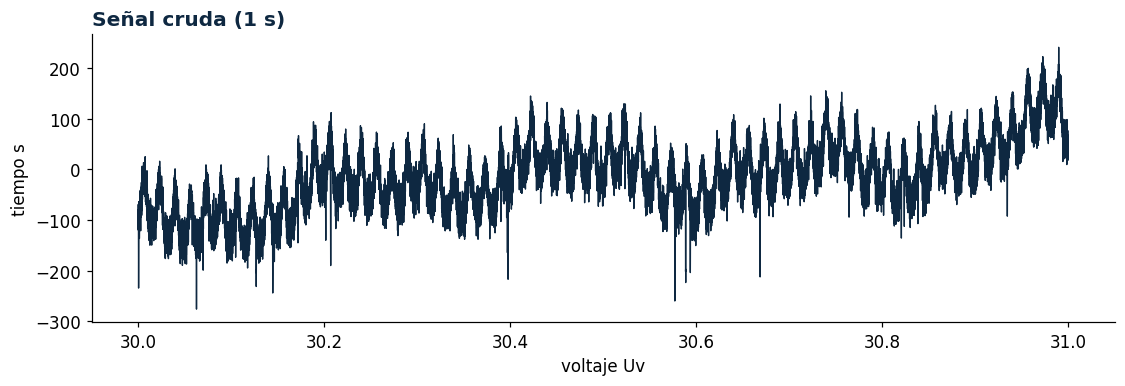

In [5]:
def ver(x, titulo, t0=30.0, t1=31.0, color=NAVY):
    """Grafica la señal x entre los tiempos t0 y t1 (en segundos)."""
    # Su código aquí: máscara de la ventana, plot, título y ejes CON UNIDADES
    m = (t >= t0) & (t <= t1)                  # máscara: True donde el tiempo cae en la ventana
    plt.figure()
    plt.plot(t[m], x[m], color=color, lw=0.9)   # ¿qué va en el eje x y qué en el eje y?
    plt.title(titulo, color=NAVY, fontweight="bold", loc="left")
    plt.xlabel("voltaje Uv")                          # no olvides las unidades
    plt.ylabel("tiempo s")


ver(cruda, "Señal cruda (1 s)", t0=30, t1=31)

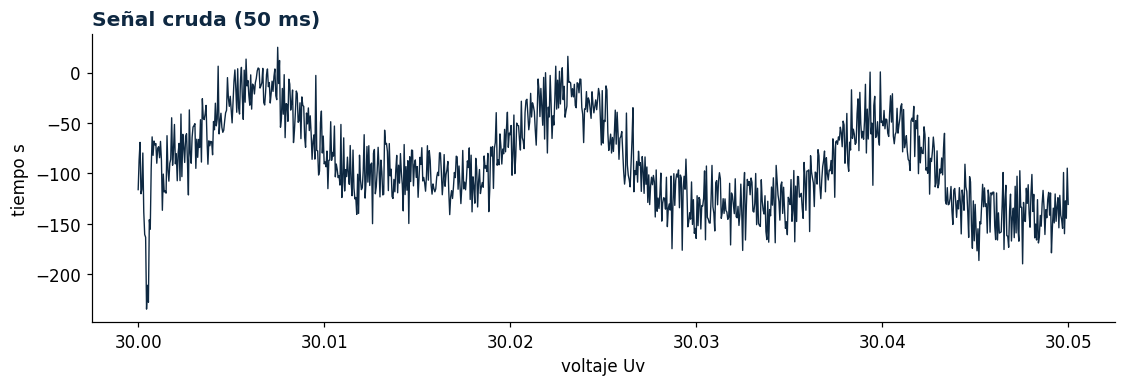

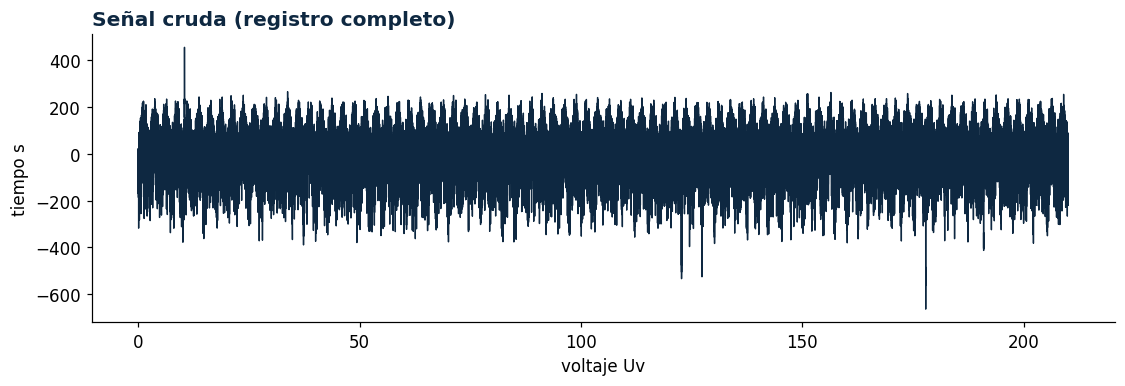

In [6]:
ver(cruda, "Señal cruda (50 ms)", t0=30.0, t1=30.05)

# Registro completo
ver(cruda, "Señal cruda (registro completo)", t0=0.0, t1=t.max())

**Los tres problemas que encontramos:**

1. Ruido electrico
2. Deriva lenta por movimientos del animal o
3. Eventos aislados como el pico de -600.

**Pregunta B2.** ¿Cuál de los tres nos impide contar los disparos a ojo, como hicimos
en la Sesión 3?
El ruido electrico impide contar de manera fácil los disparos al dar aplitudes similares a las esperadas por la neuronas dificultanod su conteo.



---
## C · Diagnosticar el ruido: el espectro de potencia

Mirar la señal en el tiempo les dice que *hay* algo raro. El **espectro de potencia** les
dice **qué** es: cuánta energía tiene la señal en cada frecuencia. Es la herramienta de
diagnóstico, y se mira **antes** de filtrar nada, porque un filtro que no hacía falta
también deforma la señal.

Qué van a buscar en él:

| En el espectro | Qué es |
|---|---|
| un **pico angosto** en una frecuencia exacta | algo instrumental: la red eléctrica |
| energía en las **frecuencias muy bajas** (< 5 Hz) | la deriva lenta |
| energía entre **300 y 3000 Hz** | los potenciales de acción |
| un **piso plano** que nunca baja | ruido térmico, presente en todas las frecuencias |

### ✍️ Ejercicio C1 · Escriban su prompt
Necesitan una función `espectro()`. En la Sesión 4 vimos **para qué** sirve el espectro y
qué se busca en él; programarlo es de hoy. Especificación:

| | |
|---|---|
| **Entradas** | `x` (array de voltaje), `fs` (frecuencia de muestreo), `etiqueta` (título), `fmax=500` |
| **Salida** | dos arrays: `f` (frecuencias, Hz) y `P` (potencia en cada frecuencia) |
| **Cómo** | con `scipy.signal.welch` y `nperseg=8192`; graficar solo hasta `fmax`, con el eje y en escala logarítmica (`plt.semilogy`), ejes rotulados con unidades |

Antes de escribirlo, repasen los **5 elementos**. Un prompt que solo diga *"hazme un
espectro"* devuelve algo que no encaja con estos datos.

_Escriban aquí su prompt:_ Estoy en Python y necesito que me des una función espectro(). Esto bajo un contexto de análisis de amplitudes neuronal. Se debe tener de entrada x (array de voltaje), fs (frecuencia de muestreo), etiqueta (título) y fmax=500. Con la entrada necesito que uses scipy.signal.welch y nperseg=8192, grafiques hasta fmax, con el eje y en escala logarítmica (plt.semilogy), teniendo los ejes rotulados con unidades. Importante: el espectro debe calcularse completo hasta la frecuencia de Nyquist (por ejemplo, 10 000 Hz si fs=20 000 Hz); fmax solo debe limitar lo que se muestra en la gráfica, no debe recortar los arrays que devuelve la función. La salida debe ser dos arrays: f (frecuencias, Hz) y P (potencia en cada frecuencia).


>

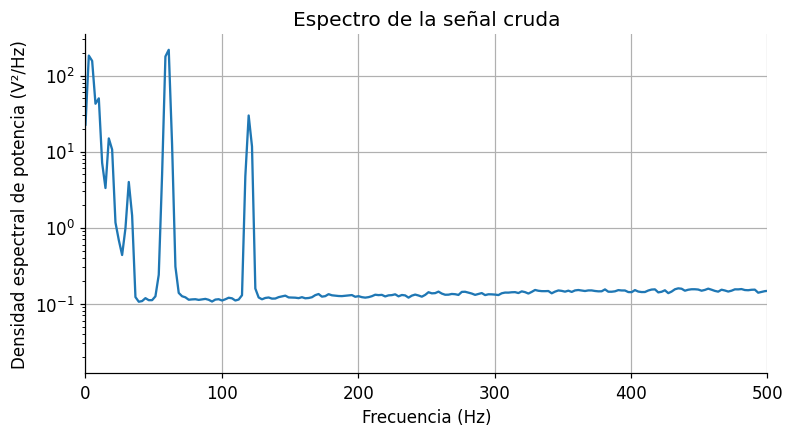

Pico dominante entre 40 y 200 Hz: 61.0 Hz


In [7]:

# Su código aquí: peguen o escriban espectro() y aplíquenla a la señal cruda.
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch

def espectro(x, fs, etiqueta, fmax=500):
    # Calcular el espectro COMPLETO
    f, P = welch(x, fs=fs, nperseg=8192)

    # Graficar el espectro completo, pero mostrar solo hasta fmax
    plt.figure(figsize=(8, 4))
    plt.semilogy(f, P)

    plt.xlabel("Frecuencia (Hz)")
    plt.ylabel("Densidad espectral de potencia (V²/Hz)")
    plt.title(etiqueta)
    plt.xlim(0, fmax)
    plt.grid(True)

    plt.show()

# Devolver el espectro COMPLETO
    return f, P
# Al final tienen que quedar definidas estas dos variables:

f, P = espectro(cruda, fs, "Espectro de la señal cruda")      # llamen a su función aquí

# Esta línea dice cuál es la frecuencia con más potencia entre 40 y 200 Hz:
m = (f > 40) & (f < 200)
pico = float(f[m][np.argmax(P[m])])
print(f"Pico dominante entre 40 y 200 Hz: {pico:.1f} Hz")

In [8]:
# ✅ VERIFICACIÓN · ejercicio C1
revisar("espectro() devuelve dos arrays del mismo tamaño",
        len(f) == len(P) and len(f) > 100,
        "welch devuelve (frecuencias, potencias): hay que retornar las dos")
revisar("las frecuencias llegan hasta Nyquist (10 000 Hz)",
        f.max() > 9000,
        "grafiquen solo hasta fmax, pero calculen el espectro completo")
revisar("el pico dominante está en la red eléctrica (~60 Hz)",
        55 < pico < 65,
        "revisen que le pasaron fs a welch y no el valor por defecto")
revisar("la potencia se concentra en 60 Hz más que en la banda del LFP (5-15 Hz)",
        pot(cruda, 55, 65, fs) > 2 * pot(cruda, 5, 15, fs))
revisar("hay energía en la banda de los potenciales de acción",
        pot(cruda, 300, 3000, fs) > 0)
print(f[1]-f[0])


  OK    espectro() devuelve dos arrays del mismo tamaño
  OK    las frecuencias llegan hasta Nyquist (10 000 Hz)
  OK    el pico dominante está en la red eléctrica (~60 Hz)
  OK    la potencia se concentra en 60 Hz más que en la banda del LFP (5-15 Hz)
  OK    hay energía en la banda de los potenciales de acción
2.44140625


**Pregunta C2.** Con números, no de memoria:

- El pico no cae exactamente en 60,0 Hz. Miren cuánto vale `f[1] - f[0]`: esa es la
  **resolución** de su espectro. ¿Explica la diferencia?
- Hay otro pico más pequeño al doble de 60 Hz. ¿Cómo se llama y de dónde sale?
- La deriva lenta (0.4 Hz) se ve clarísima en la señal. ¿Aparece como un pico en el espectro? Miren
  cuánto dura un segmento de Welch (`nperseg / fs`, en segundos) y compárenlo con el
  período de la deriva (1/0,4 Hz = 2,5 s). ¿Cabe siquiera un ciclo dentro del segmento?
  Repitan el espectro con `nperseg = 200000` y miren qué aparece por debajo de 1 Hz.
  ¿Qué se dañó a cambio?
- ¿Por qué el eje y va en escala logarítmica? Vuelvan a graficar con `plt.plot` en vez de
  `plt.semilogy` y digan qué dejan de ver.

_Escriban su respuesta aquí:_

El pico no cae exactamente en 60 Hz por lo que tiene un resolución de de 2.4, por lo que el pico estaría un poco movido.

Sale a 120 Hz y es posible que al ser un  multiplo del ruido eléctrico de 60 Hz sea este otro componente que venga en el ruido de la señal electrica.

Se puede ver un pico cercano a 0 con este valor. Al tener tsegmento es de Welch 0.4091s y 2.5s  deriva lenta por lo que en el periodo Welch no cabe un ciclo de la revida lenta nperseg = 200000






## D · Filtrar (una sola vez, dos bandas)

La señal es una **mezcla** de cosas que ocurren a velocidades distintas:

| Componente | Qué es | Banda |
|---|---|---|
| **Deriva** | movimiento, cambios de temperatura, electroquímica del electrodo | < 5 Hz |
| **LFP** | corrientes sinápticas sumadas de muchas neuronas | < 300 Hz |
| **60 Hz** | red eléctrica, y su armónico en 120 Hz | 60 y 120 Hz |
| **Potenciales de acción** | los disparos de las neuronas cercanas | 300 a 5000 Hz |
| **Ruido térmico** | agitación de los electrones en el electrodo y la electrónica | todas |

Cortar en 300 Hz es una convención del oficio, no una ley de la naturaleza: en la
pregunta D4 van a ver qué tan arbitraria es.


### ✍️ Ejercicio D1 · Escriban su prompt

Necesitan **una sola** función de filtrado que sirva para los dos casos. También es nueva:
en la Sesión 4 vimos qué le hace un filtro a una señal, no cómo se escribe.

| | |
|---|---|
| **Entradas** | `x` (señal), `fs`, `baja=None` (corte inferior), `alta=None` (corte superior), `orden=3` |
| **Salida** | la señal filtrada, del mismo tamaño que `x` |
| **Cómo** | filtro **Butterworth**; si solo se da `alta`, es pasa-bajos; si solo se da `baja`, es pasa-altos; si se dan las dos, pasa-banda |
| **Exigencias** | fase cero (`filtfilt` o `sosfiltfilt`) y frecuencias normalizadas por Nyquist |

La **fase cero** no es un capricho: un filtro normal retrasa la señal, y el retraso depende
de la frecuencia. Si filtran así, los disparos se les mueven en el tiempo y todo lo que
midan después queda corrido — y las figuras van a salir igual de creíbles.


_Escriban aquí su prompt: “Quiero una función de filtrado llamada filtrar() que reciba:
x (señal), fs (frecuencia de muestreo), baja=None, alta=None, orden=3.
La función debe aplicar un filtro Butterworth con fase cero usando filtfilt.

Reglas:

Si solo se da alta, debe ser pasa‑bajos.

Si solo se da baja, debe ser pasa‑altos.

Si se dan ambas, debe ser pasa‑banda.

Las frecuencias deben estar normalizadas por Nyquist.

La salida debe tener el mismo tamaño que x.

No cambiar nombres de variables existentes.

No graficar dentro de la función.

No usar lfilter (introduce retardo).

No usar filtros FIR ni funciones externas.

Solo usar NumPy y SciPy."
>

<Figure size 1320x374 with 0 Axes>

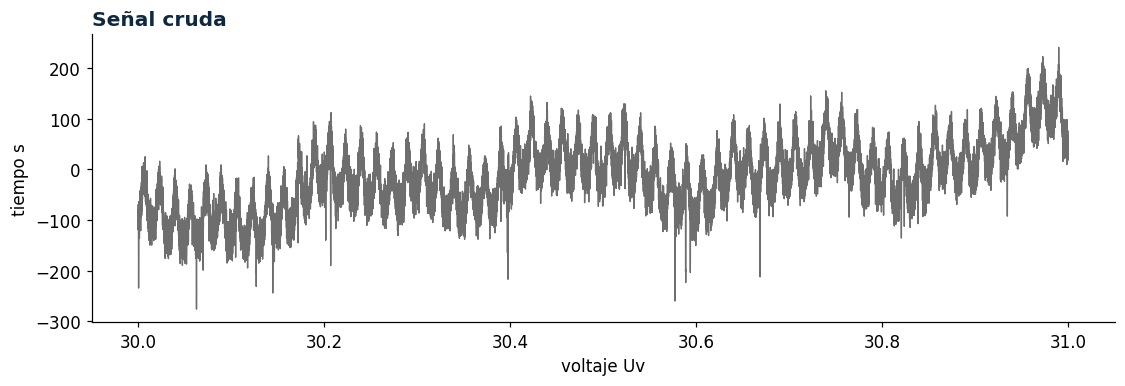

<Figure size 1320x374 with 0 Axes>

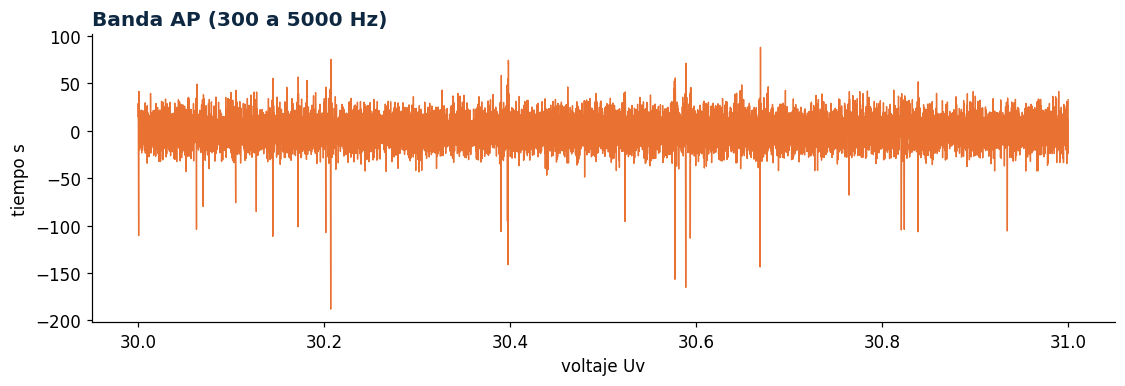

In [9]:
# Su código aquí: la función filtrar(), y con ella la banda de los potenciales de acción.
import numpy as np
from scipy.signal import butter, filtfilt

def filtrar(x, fs, baja=None, alta=None, orden=3):
    """
    Filtro Butterworth con fase cero.
    - pasa-bajos si solo alta
    - pasa-altos si solo baja
    - pasa-banda si baja y alta
    """
    nyq = fs / 2

    if baja is None and alta is None:
        return x.copy()
    if baja is None:  # pasa-bajos
        Wn = alta / nyq
        b, a = butter(orden, Wn, btype='low')
    elif alta is None:  # pasa-altos
        Wn = baja / nyq
        b, a = butter(orden, Wn, btype='high')
    else:  # pasa-banda
        Wn = [baja / nyq, alta / nyq]
        b, a = butter(orden, Wn, btype='band')

    xf = filtfilt(b, a, x)
    return xf
AP =   filtrar(cruda, fs, baja=300, alta=5000, orden=3)    # pasa-banda de 300 a 5000 Hz sobre la señal cruda

plt.figure(); ver(cruda, "Señal cruda", t0=30.0, t1=31.0, color=GRAY)
plt.figure(); ver(AP, "Banda AP (300 a 5000 Hz)", t0=30.0, t1=31.0, color=ORANGE)

In [10]:
# ✅ VERIFICACIÓN · ejercicio D1
print(f"sigma robusta   ·   cruda: {np.median(np.abs(cruda))/0.6745:6.1f} µV"
      f"   ·   AP: {np.median(np.abs(AP))/0.6745:6.1f} µV")
print(f"potencia en 60 Hz   ·   cruda: {pot(cruda,55,65,fs):9.1f}"
      f"   ·   AP: {pot(AP,55,65,fs):9.4f}\n")

revisar("la banda AP tiene el mismo tamaño que la señal original",
        len(AP) == len(cruda), "filtfilt devuelve una señal de la misma longitud")
revisar("la banda AP botó la deriva y el LFP",
        pot(AP, 0, 50, fs) < 0.001 * pot(cruda, 0, 50, fs),
        "si sobrevive lo lento, el filtro quedó como pasa-bajos")
revisar("la banda AP botó el ruido de red de 60 Hz",
        pot(AP, 55, 65, fs) < 0.001 * pot(cruda, 55, 65, fs))
revisar("la banda AP conservó los potenciales de acción (300-3000 Hz)",
        pot(AP, 300, 3000, fs) > 0.5 * pot(cruda, 300, 3000, fs))
revisar("el ruido de la banda AP es mucho menor que el de la señal cruda",
        np.median(np.abs(AP))/0.6745 < 0.4 * (np.median(np.abs(cruda))/0.6745))

sigma robusta   ·   cruda:   70.8 µV   ·   AP:   13.5 µV
potencia en 60 Hz   ·   cruda:     413.8   ·   AP:    0.0000

  OK    la banda AP tiene el mismo tamaño que la señal original
  OK    la banda AP botó la deriva y el LFP
  OK    la banda AP botó el ruido de red de 60 Hz
  OK    la banda AP conservó los potenciales de acción (300-3000 Hz)
  OK    el ruido de la banda AP es mucho menor que el de la señal cruda


**Pregunta D2**

En la Sesión vimos que un filtro **notch** sirve para eliminar frecuencias específicas, como la de 60 Hz. Aquí no hizo falta ninguno y la
verificación acaba de decirles que la banda AP ya no tiene nada en 60 Hz.

- Miren en qué banda está el ruido de red y en qué banda están los disparos, y expliquen en
  dos líneas **por qué el pasa-banda hace el trabajo del notch** en este caso.
- ¿Qué le pasó a la deriva? ¿Y a los artefactos enormes que encontraron en la sección B?
- Entonces, ¿**cuándo** sí haría falta un notch? (Piensen qué quieren conservar.)

_Escriban su respuesta aquí:_
El pasa-banda de **300-5000** Hz hace el trabajo del notch en este caso ya que elimina el ruido de 60/120 Hz al ser menores de **300** Hz como la deriva y el LFP. El notch se usaría solo cuando el ruido de 60 Hz cae dentro de la banda que quieres conservar, lo que pasa en LFP.

### 📋 Ejercicio D3 · La otra banda: LFP, y ahí sí el notch

La respuesta a la última pregunta es: cuando lo que quieren conservar es **lo lento**. La
banda LFP vive por debajo de 300 Hz, y los 60 Hz están justo en medio: un pasa-bajos no los
puede quitar sin llevarse la señal biológica. Para eso está el *notch*, que elimina una
franja **muy angosta** y deja el resto casi intacto.

Copien este prompt **tal cual** en ChatGPT o Claude. Lean la respuesta completa antes de
usarla:

> Trabajo en Python con numpy y scipy. Tengo un array `cruda` con el voltaje (en µV) de un
> registro extracelular muestreado a 20000 Hz, contaminado con ruido de red eléctrica en
> 60 Hz y su armónico en 120 Hz. Escríbeme una función `notch(x, f0, fs, Q=30)` que use
> `scipy.signal.iirnotch` para diseñar el filtro y `scipy.signal.filtfilt` para aplicarlo.
> Explícame qué controla el parámetro `Q` y por qué en electrofisiología se usa `filtfilt`
> y no `lfilter`. Rotula todo con unidades y explícame cada línea.

Antes de correr nada, contesten: **¿el código que les dio sirve, o le sobra o le falta
algo?** Fíjense sobre todo en si le pasa la frecuencia de muestreo al diseñar el filtro:
es el error más común.

Después obtengan la banda LFP: quiten 60 y 120 Hz con el notch, y **luego** apliquen su
`filtrar()` como pasa-bajos de 300 Hz.

<Figure size 1320x374 with 0 Axes>

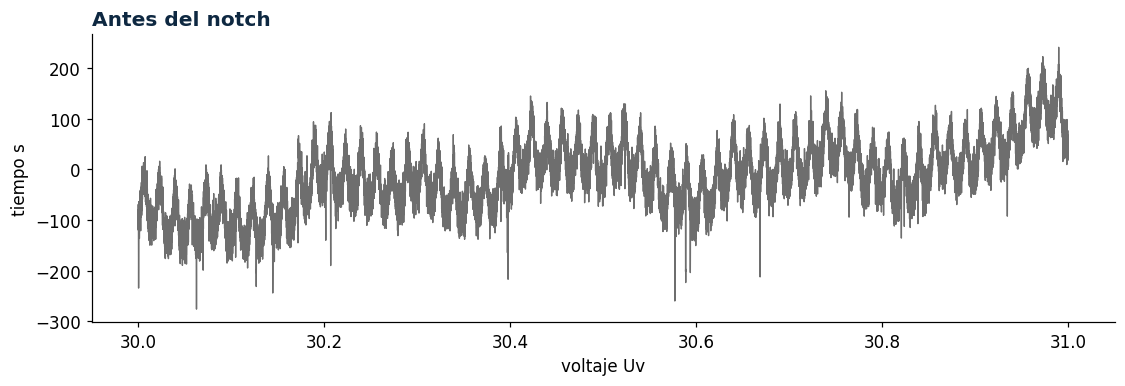

<Figure size 1320x374 with 0 Axes>

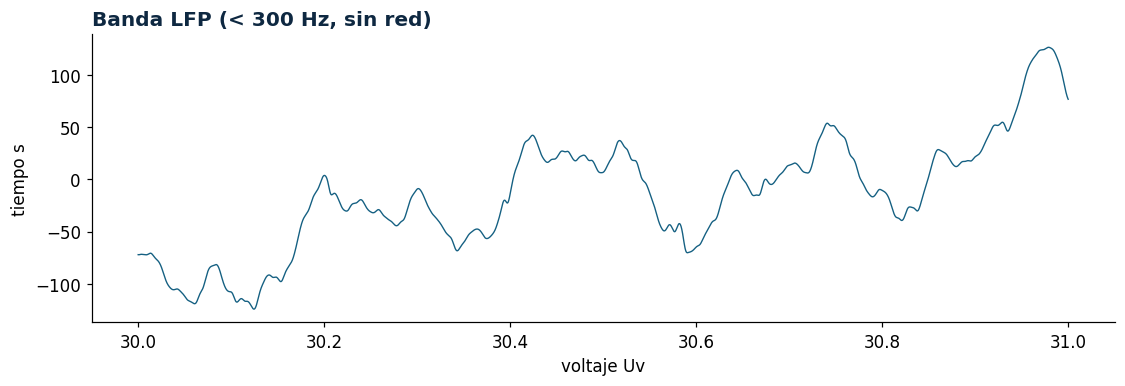

In [11]:
import numpy as np
from scipy.signal import iirnotch, filtfilt

def notch(x, f0, fs, Q=30):
    # Diseñar el filtro notch
    b, a = iirnotch(w0=f0, Q=Q, fs=fs)

    # Aplicar el filtro hacia adelante y hacia atrás
    y = filtfilt(b, a, x)

    return y
# Ojo: son DOS frecuencias, 60 y 120 Hz.

sin_red_60 = notch(cruda, f0=60, fs=fs)            # la señal cruda sin ruido de red a 60 Hz
sin_red    = notch(sin_red_60, f0=120, fs=fs)       # la señal sin ruido de red a 60 y 120 Hz
LFP        = filtrar(sin_red, fs, alta=100)         # pasa-bajos de 300 Hz sobre sin_red

plt.figure(); ver(cruda, "Antes del notch", t0=30.0, t1=31.0, color=GRAY)
plt.figure(); ver(LFP,   "Banda LFP (< 300 Hz, sin red)", t0=30.0, t1=31.0, color=TEAL)

In [12]:
# ✅ VERIFICACIÓN · ejercicio D3
caida_60  = 10*np.log10(pot(cruda,  55,  65, fs) / pot(sin_red,  55,  65, fs))
caida_120 = 10*np.log10(pot(cruda, 115, 125, fs) / pot(sin_red, 115, 125, fs))
cambio_lento = abs(10*np.log10(pot(cruda, 5, 15, fs) / pot(sin_red, 5, 15, fs)))
print(f"caída en 60 Hz: {caida_60:.1f} dB   ·   en 120 Hz: {caida_120:.1f} dB")
print(f"cambio en la banda del LFP (5-15 Hz): {cambio_lento:.2f} dB\n")

revisar("el notch bajó los 60 Hz al menos 10 dB", caida_60 > 10,
        "revisen que le pasaron fs=20000 a iirnotch")
revisar("también quitaron el armónico de 120 Hz", caida_120 > 10,
        "hay que aplicar el notch dos veces, una por cada frecuencia")
revisar("el notch NO tocó la banda del LFP", cambio_lento < 1.0,
        "si el LFP también cayó, la Q es demasiado baja: el notch quedó muy ancho")
revisar("el LFP es mucho más grande que la banda AP",
        LFP.std() > 3 * AP.std(),
        "en un registro extracelular casi toda la varianza está en lo lento")

caída en 60 Hz: 31.6 dB   ·   en 120 Hz: 24.1 dB
cambio en la banda del LFP (5-15 Hz): 0.00 dB

  OK    el notch bajó los 60 Hz al menos 10 dB
  OK    también quitaron el armónico de 120 Hz
  OK    el notch NO tocó la banda del LFP
  OK    el LFP es mucho más grande que la banda AP


**Pregunta D4.** Dos experimentos cortos y una conclusión:

- Apliquen un notch en **9 Hz**, donde sí hay señal biológica. Grafiquen antes y después y
  digan qué le pasó al LFP.
- Vuelvan al notch de 60 Hz pero con `Q = 2`. ¿Qué controla Q? Grafiquen el espectro
  resultante: ¿qué se llevó por delante?
- Repitan el pasa-banda de la banda AP moviendo el corte inferior a **100 Hz** y a
  **800 Hz**. ¿Qué se cuela con 100 Hz? ¿Qué le pasa a la **forma** de los disparos con
  800 Hz? Si tuvieran que justificar el corte de 300 Hz en un artículo, ¿qué dirían?

Con eso, contesten en una línea: **¿por qué el diagnóstico va antes del filtrado?**

_Escriban su respuesta aquí:_
Al usar 9 Hz  se elimina parte de la señal biologica, perdiendose señal de esta.  
Q controla que tan grande o pequeño es notch y se llevo la anchura de los picos.
Con 100 se puede ver pocos picos por lo que entrean componentes de variación lenta y con 800 se ve al reves por se eliminan componentes de acción, como 300 es un punto medio sirve.





<Figure size 1320x374 with 0 Axes>

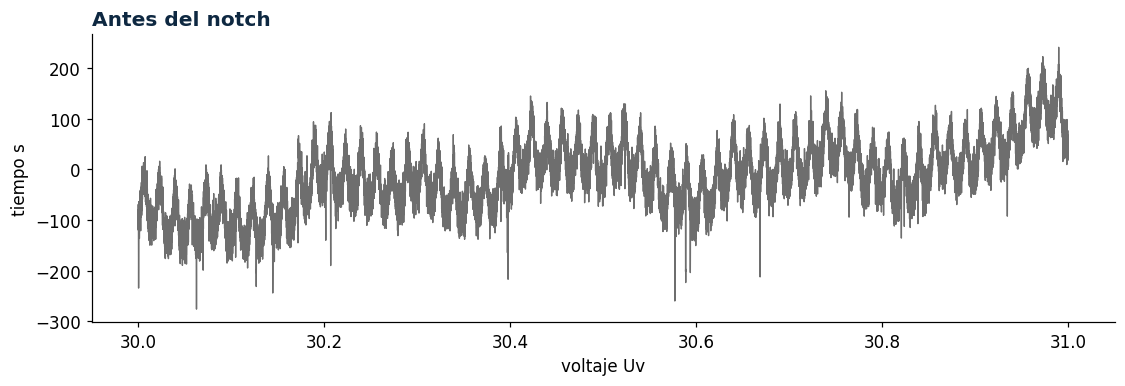

<Figure size 1320x374 with 0 Axes>

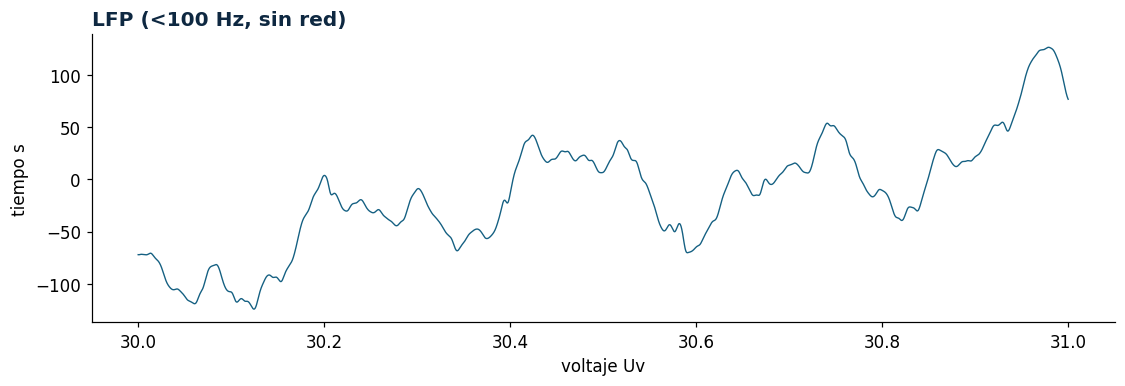

<Figure size 1320x374 with 0 Axes>

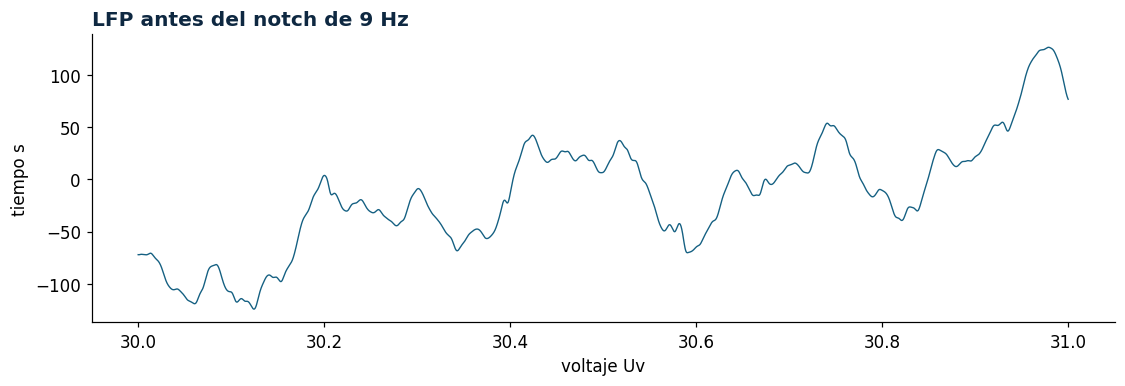

<Figure size 1320x374 with 0 Axes>

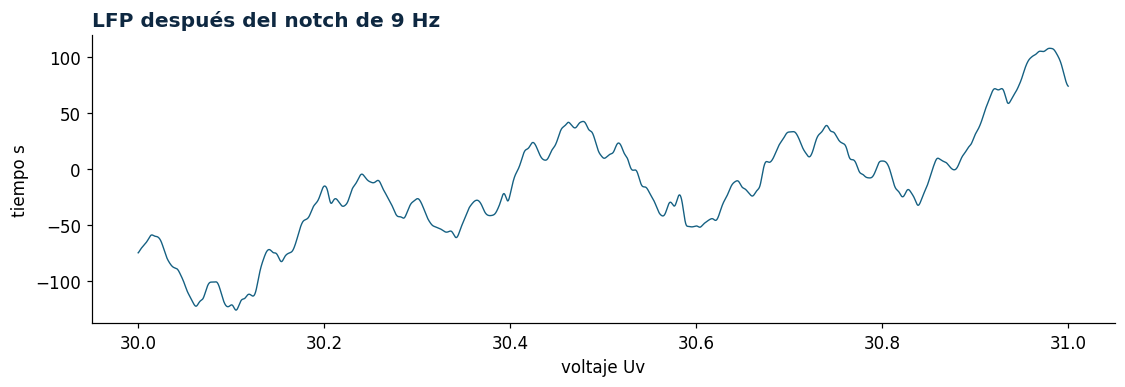

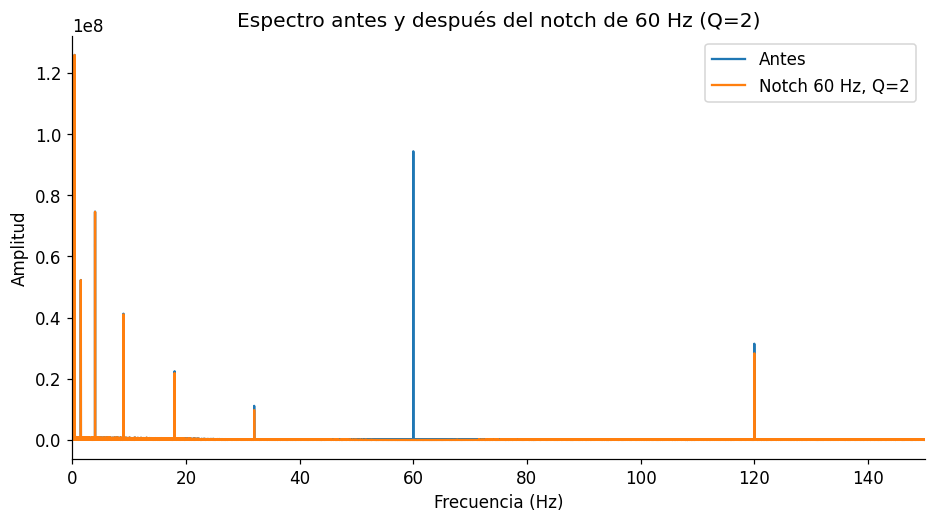

<Figure size 1320x374 with 0 Axes>

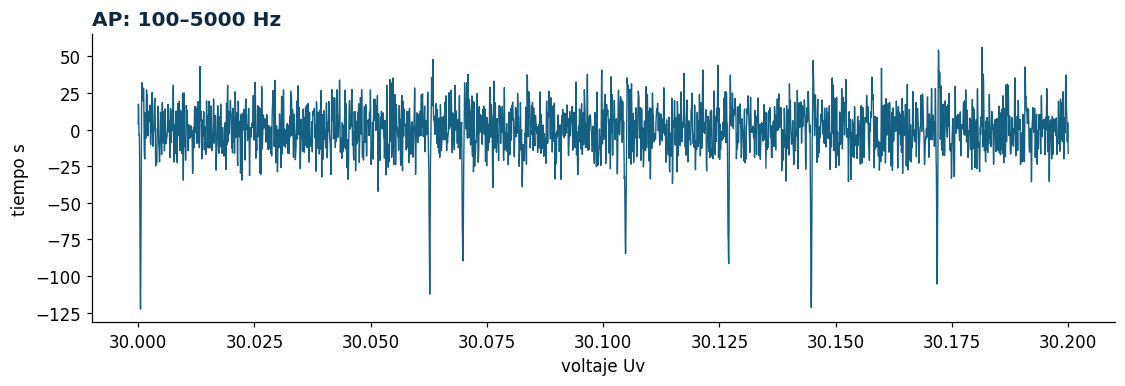

<Figure size 1320x374 with 0 Axes>

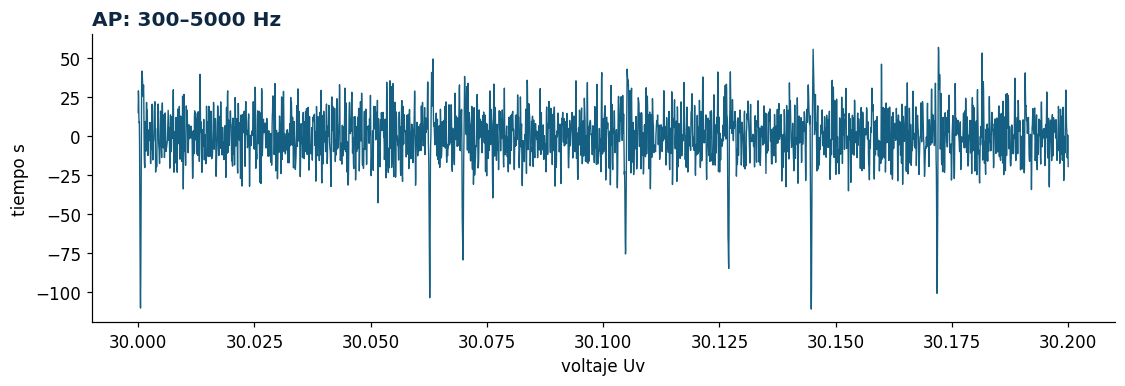

<Figure size 1320x374 with 0 Axes>

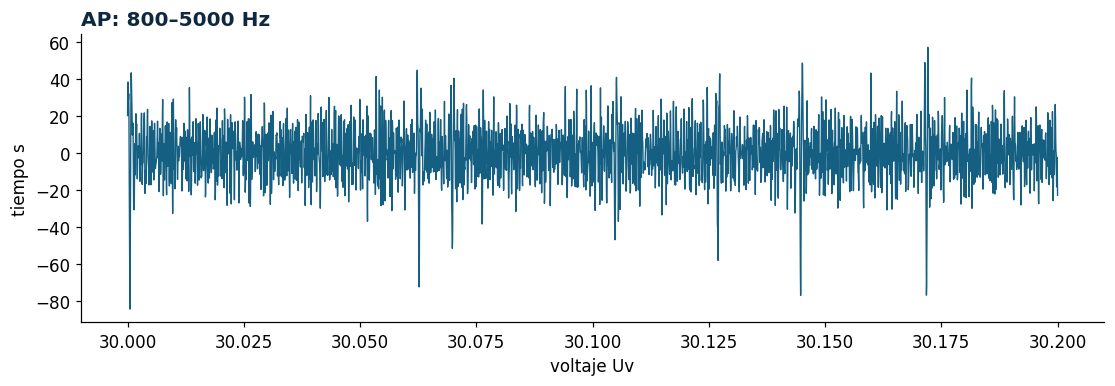

In [13]:
import numpy as np
from scipy.signal import iirnotch, filtfilt

def notch(x, f0, fs, Q=30):
    # Diseñar el filtro notch
    b, a = iirnotch(w0=f0, Q=Q, fs=fs)

    # Aplicar el filtro hacia adelante y hacia atrás
    y = filtfilt(b, a, x)

    return y


# ============================================================
# 1. NOTCH DE 60 Y 120 Hz
# ============================================================

# Q = 30: notch estrecho para eliminar la frecuencia de red
sin_red_60 = notch(cruda, f0=60, fs=fs, Q=30)

# Eliminar también el segundo armónico de 120 Hz
sin_red = notch(sin_red_60, f0=120, fs=fs, Q=30)

# Obtener el LFP (< 100 Hz)
LFP = filtrar(sin_red, fs, alta=100)

# Graficar señal antes y después
plt.figure()
ver(cruda, "Antes del notch", t0=30.0, t1=31.0, color=GRAY)

plt.figure()
ver(LFP, "LFP (<100 Hz, sin red)", t0=30.0, t1=31.0, color=TEAL)


# ============================================================
# 2. NOTCH EN 9 Hz
# ============================================================

# Aplicar notch en 9 Hz
sin_9 = notch(sin_red, f0=9, fs=fs, Q=30)

# Obtener el LFP después del notch
LFP_9 = filtrar(sin_9, fs, alta=100)

# Graficar antes del notch de 9 Hz
plt.figure()
ver(LFP, "LFP antes del notch de 9 Hz", t0=30.0, t1=31.0, color=TEAL)

# Graficar después del notch de 9 Hz
plt.figure()
ver(LFP_9, "LFP después del notch de 9 Hz", t0=30.0, t1=31.0, color=TEAL)


# ============================================================
# 3. NOTCH DE 60 Hz CON Q = 2
# ============================================================

# Aplicar notch de 60 Hz con Q = 2
sin_60_Q2 = notch(cruda, f0=60, fs=fs, Q=2)

# Espectro de la señal original
freq = np.fft.rfftfreq(len(cruda), 1/fs)
espectro_cruda = np.abs(np.fft.rfft(cruda))

# Espectro después del notch
espectro_Q2 = np.abs(np.fft.rfft(sin_60_Q2))

# Graficar espectros
plt.figure(figsize=(10, 5))

plt.plot(freq, espectro_cruda, label="Antes")
plt.plot(freq, espectro_Q2, label="Notch 60 Hz, Q=2")

plt.xlim(0, 150)
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("Amplitud")
plt.title("Espectro antes y después del notch de 60 Hz (Q=2)")
plt.legend()
plt.show()


# ============================================================
# 4. PASA-BANDA PARA AP
# ============================================================

# Corte inferior de 100 Hz
AP_100 = filtrar(sin_red, fs, baja=100, alta=5000)

# Corte inferior de 300 Hz
AP_300 = filtrar(sin_red, fs, baja=300, alta=5000)

# Corte inferior de 800 Hz
AP_800 = filtrar(sin_red, fs, baja=800, alta=5000)


# ============================================================
# 5. COMPARAR LAS TRES SEÑALES
# ============================================================

plt.figure()
ver(AP_100, "AP: 100–5000 Hz", t0=30.0, t1=30.2, color=TEAL)

plt.figure()
ver(AP_300, "AP: 300–5000 Hz", t0=30.0, t1=30.2, color=TEAL)

plt.figure()
ver(AP_800, "AP: 800–5000 Hz", t0=30.0, t1=30.2, color=TEAL)

---
## E · Detectar los disparos · **el ejercicio central**

### ✏️ Ejercicio E1 · El detector

Escriban una función que reciba la señal filtrada y devuelva los índices de las muestras
donde hay un potencial de acción.

**La especificación es esta y no la pueden cambiar:**

```
detectar_spikes(x, fs, k=4.5, muerto_ms=1.5) -> np.ndarray de índices enteros
```

| | |
|---|---|
| `x` | señal **filtrada**, en µV |
| `fs` | frecuencia de muestreo, en Hz |
| `k` | cuántas veces el nivel de ruido se pone el umbral |
| `muerto_ms` | tiempo mínimo entre dos detecciones consecutivas |
| **devuelve** | los índices de las muestras donde ocurre cada disparo, ordenados y sin repetir |

**Cuatro decisiones que la función tiene que resolver.** Están enunciadas como preguntas a
propósito: si le piden a la IA "escribe un detector de spikes", casi seguro se equivocará
en al menos dos de ellas.

1. **¿Hacia dónde apunta un potencial de acción extracelular?** Miren un evento de cerca
   antes de decidir.
2. **¿Cómo se fija el umbral?** Un valor fijo en microvoltios no sirve. Hay que medir el
   ruido y poner el umbral en `k` veces esa medida. Y ojo con la trampa: la desviación
   estándar está inflada por los propios disparos. Busquen **MAD** (*median absolute
   deviation*) y por qué se divide por 0,6745:

   $$\hat{\sigma} = \frac{\text{mediana}(|x|)}{0{,}6745}, \qquad \text{umbral} = -k\,\hat{\sigma}$$

3. **Un disparo cruza el umbral durante varias muestras seguidas.** Si marcan cada muestra
   que cruza, cuentan el mismo evento muchas veces. Hay que agrupar las muestras contiguas
   y quedarse con **una** por evento. ¿Con cuál?
4. **El período muerto.** Después de marcar un evento hay que saltar `muerto_ms` hacia
   adelante. El valor por defecto, 1,5 ms, viene del período refractario de una neurona.
   En la sección F van a descubrir por qué aquí eso es discutible.

In [14]:
def detectar_spikes(x, fs, k=4.5, muerto_ms=1.5):
    """Devuelve los índices de las muestras donde hay un potencial de acción."""

    # 1. Signo del potencial de acción extracelular (picos negativos)
    # 2. Umbral robusto con MAD
    sigma = np.median(np.abs(x)) / 0.6745
    umbral = -k * sigma

    # Encontrar los cruces del umbral
    cruces = np.where(x < umbral)[0]

    indices_detectados = []
    if len(cruces) == 0:
        return np.array([], dtype=int)

    # 3. Agrupar muestras contiguas y quedarse con una por evento (el mínimo)
    # 4. Período muerto
    ultimo_detectado = -np.inf # Initialize with a value that ensures the first spike is detected
    muerto_muestras = int(muerto_ms * fs / 1000)

    # Iterate through the indices where the signal crosses the threshold
    i = 0
    while i < len(cruces):
        current_spike_start_idx = cruces[i]

        # Check for dead period constraint
        if current_spike_start_idx > ultimo_detectado + muerto_muestras:
            # Find the end of the current crossing event
            j = i
            while j < len(cruces) and cruces[j] == cruces[i] + (j - i):
                j += 1
            current_spike_end_idx = cruces[j-1]

            # Find the minimum within this crossing event
            # Consider the actual samples of the signal within this window
            # To ensure we capture the whole event, look a bit before the start and after the end of the threshold crossing
            # Or, for simplicity, find the minimum within the detected contiguous segment
            segment_start = current_spike_start_idx
            segment_end = current_spike_end_idx + 1 # Include the end index

            if segment_start >= len(x): # Handle cases where segment might go out of bounds at the end
                i = j
                continue

            # Adjust segment_end to not exceed array bounds
            segment_end = min(segment_end, len(x))

            # Find the index of the minimum value within the contiguous block that crossed the threshold
            # Ensure the segment has at least one element
            if segment_start < segment_end:
                min_idx_in_segment = segment_start + np.argmin(x[segment_start:segment_end])
                indices_detectados.append(min_idx_in_segment)
                ultimo_detectado = min_idx_in_segment # Update last detected spike time

        i += 1 # Move to the next potential spike after the dead period or current crossing event

    return np.array(indices_detectados, dtype=int)


indices = detectar_spikes(AP, fs)
tiempos = indices / fs                    # índices -> segundos
sigma   = np.median(np.abs(AP)) / 0.6745
umbral  = -4.5 * sigma

print(f"sigma del ruido ≈ {sigma:.1f} µV   ·   umbral = {umbral:.1f} µV")
print(f"detectados: {len(indices)} disparos en {len(AP)/fs:.0f} s "
      f"({len(indices)/(len(AP)/fs):.1f} por segundo)")

sigma del ruido ≈ 13.5 µV   ·   umbral = -60.9 µV
detectados: 5463 disparos en 210 s (26.0 por segundo)


In [15]:
# ✅ VERIFICACIÓN · ejercicio E1
indices = np.asarray(indices)
revisar("detectar_spikes() devuelve índices enteros, no tiempos",
        indices.dtype.kind in "iu" and indices.max() < len(AP),
        "los índices son posiciones en el array; los tiempos salen después, con indices/fs")
revisar("el número de detecciones es plausible (entre 4000 y 7000)",
        4000 <= len(indices) <= 7000,
        "si salen decenas de miles, no están agrupando los cruces; si salen cientos, el umbral es muy exigente")
revisar("todos los índices caen por debajo del umbral",
        bool(np.all(AP[indices] < umbral)),
        "están guardando el índice del cruce o del final de la ventana, no el del mínimo")
revisar("no hay dos detecciones separadas por menos del período muerto",
        bool(np.all(np.diff(indices) >= 0.0015*fs - 1)),
        "después de marcar un evento hay que saltar muerto_ms hacia adelante")
revisar("los índices salen ordenados en el tiempo",
        bool(np.all(np.diff(indices) > 0)))

  OK    detectar_spikes() devuelve índices enteros, no tiempos
  OK    el número de detecciones es plausible (entre 4000 y 7000)
  OK    todos los índices caen por debajo del umbral
  OK    no hay dos detecciones separadas por menos del período muerto
  OK    los índices salen ordenados en el tiempo


### ✏️ Ejercicio E2 · La figura de control

Una figura que muestre el resultado: la banda AP, la línea del umbral y un marcador sobre
el pico de cada disparo detectado, en una ventana de **200 ms**.

Fíjense en la línea de `d`: selecciona solo las detecciones que caen dentro de la ventana
que están graficando. Sin eso, matplotlib intenta dibujar marcadores fuera del eje y la
figura queda comprimida.

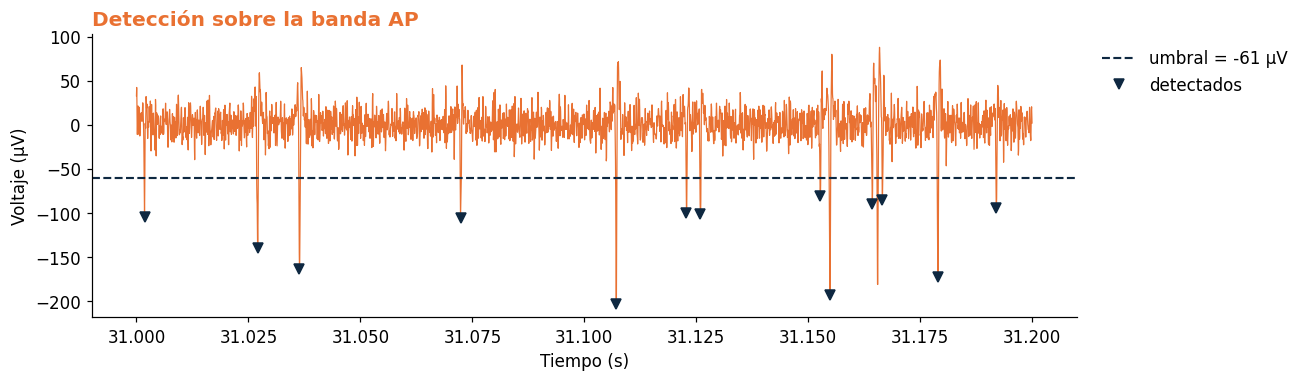

In [16]:
t0, t1 = 31.0, 31.2
m = (t >= t0) & (t < t1)
d = indices[(tiempos >= t0) & (tiempos < t1)]      # detecciones dentro de la ventana

plt.figure(figsize=(12, 3.6))
plt.plot(t[m], AP[m], color=ORANGE, lw=0.8)
plt.axhline(umbral, color=NAVY, ls="--", lw=1.4, label=f"umbral = {umbral:.0f} µV")
plt.plot(t[d], AP[d], "v", color=NAVY, ms=7, ls="none", label="detectados")
plt.xlabel("Tiempo (s)"); plt.ylabel("Voltaje (µV)")
plt.title("Detección sobre la banda AP", color=ORANGE, fontweight="bold", loc="left")
plt.legend(frameon=False, loc="upper left", bbox_to_anchor=(1.01, 1))
plt.tight_layout()

✅ **Revisen la figura a ojo:**

- [ ] Los triángulos caen **encima** del pico de cada evento, no flotando ni desplazados.
- [ ] No hay ningún disparo evidente sin su triángulo.
- [ ] No hay triángulos sobre puntos que claramente son ruido.
- [ ] Hay leyenda y los ejes tienen unidades.

Si algo falla, arreglen la función antes de seguir: todo lo que viene la usa.

---
## F · ¿Le acertamos?

Su detector devolvió miles de instantes. Hasta aquí no saben si son buenos: *"detecté
5 400 disparos"* no dice nada por sí solo. **La pregunta es cuáles.**

### Los tres números

| | |
|---|---|
| **VP** verdadero positivo | detectaron algo y ahí había un disparo de verdad |
| **FP** falso positivo | detectaron algo donde no había nada: ruido que cruzó el umbral |
| **FN** falso negativo | había un disparo y no lo detectaron |

De ahí salen las dos medidas que van a reportar:

$$\text{precisión} = \frac{VP}{VP + FP} \qquad\qquad \text{exhaustividad} = \frac{VP}{VP + FN}$$

**Precisión** responde *de lo que detecté, ¿cuánto es real?* (si es baja, están inventando
disparos). **Exhaustividad** responde *de lo que había, ¿cuánto encontré?* (si es baja, se
les están escapando). Las dos se mueven en direcciones opuestas cuando mueven el umbral, y
ahí está toda la gracia del ejercicio F2.

### Dos detalles que casi nadie acierta a la primera

**1. La tolerancia.** Su detector no marca el evento en el instante exacto: devuelve el
instante del mínimo, que llega una fracción de milisegundo después del inicio real. Es un
desfase sistemático, no un error. Por eso no se puede exigir coincidencia exacta: hay que
fijar una **ventana de tolerancia** (aquí, 1 ms) dentro de la cual dos marcas cuentan como
la misma.

**2. No reutilizar.** Cada disparo real puede emparejarse con **una sola** detección. Si no
lo imponen, dos detecciones sobre el mismo evento cuentan las dos como aciertos y su
precisión sale inflada.

### ✍️ Ejercicio F1 · Escriban su prompt

```
emparejar(detectados_s, reales_s, tol_ms=1.0) -> (VP, FP, FN)
```

Los tiempos vienen ordenados. Escríbanla ustedes con ayuda del modelo, y **especifiquen
las dos reglas de arriba en el prompt**: si no lo hacen, el código que les devuelva va a
contar mal y va a correr perfectamente.

_Escriban aquí su prompt:_ Estoy en pyhon sobre analisis de potenciales de neuronas. De entrada tengo detectados_s, reales_s, tol_ms=1.0 además de verdadero positivo (VP), falso postivo (FP) y falso negativo (FN). Necesito que empajeres estos para poder determimar la presicion Vp/VP+FP y exactitud VP/VP+FN. recuerda que solo debe emparejarse un dipsaro real con una detencion y la ventana de tolerancia es de 1ms. Explica cada linea y de recuerda que emparejar(detectados_s, reales_s, tol_ms=1.0) -> (VP, FP, FN)

>

In [17]:
import verificacion as v
v.usar(ARCHIVO)                       # el módulo del curso; aquí solo le pedimos la verdad

reales = v.spikes_de_referencia()     # los tiempos reales, en segundos

# Su código aquí: la función emparejar(), y con ella los tres números.
import numpy as np

def emparejar(detectados_s, reales_s, tol_ms=1.0):
    # Convertimos la tolerancia de milisegundos a segundos
    tol_s = tol_ms / 1000

    # Convertimos las listas a arrays para facilitar las operaciones
    detectados_s = np.asarray(detectados_s)
    reales_s = np.asarray(reales_s)

    # Guardamos cuáles detecciones ya fueron utilizadas
    usados = np.zeros(len(detectados_s), dtype=bool)

    # Contador de verdaderos positivos
    VP = 0

    # Para cada disparo real
    for real in reales_s:

        # Distancia temporal entre ese disparo real y todas las detecciones
        distancias = np.abs(detectados_s - real)

        # Solo consideramos detecciones dentro de la tolerancia
        candidatos = np.where((distancias <= tol_s) & (~usados))[0]

        # Si encontramos al menos una detección disponible
        if len(candidatos) > 0:

            # Elegimos la detección más cercana al disparo real
            mejor = candidatos[np.argmin(distancias[candidatos])]

            # Marcamos esa detección como utilizada
            usados[mejor] = True

            # Contamos un verdadero positivo
            VP += 1

    # Las detecciones que nunca se emparejaron son falsos positivos
    FP = np.sum(~usados)

    # Los disparos reales que no tuvieron pareja son falsos negativos
    FN = len(reales_s) - VP

    return VP, FP, FN

VP, FP, FN = emparejar(tiempos, reales)
print(f"VP = {VP}   FP = {FP}   FN = {FN}")
print(f"precisión     = {VP/(VP+FP):.3f}")
print(f"exhaustividad = {VP/(VP+FN):.3f}")

Verificación configurada con: taller1_datos.h5
Cargados 5623 tiempos de spike de referencia.
Ojo: son la verdad, así que verificar_deteccion sobre ellos dará 100 %.
VP = 5459   FP = 4   FN = 164
precisión     = 0.999
exhaustividad = 0.971


In [18]:
# ✅ VERIFICACIÓN · ejercicio F1
# El módulo del curso hace exactamente lo que ustedes acaban de programar: misma
# tolerancia de 1 ms y misma regla de no reutilizar. Sus números y los suyos TIENEN
# que coincidir. Si no coinciden, el que está mal es el de ustedes, y encontrar
# en qué es parte del ejercicio.
precision, exhaustividad = v.verificar_deteccion(tiempos)

revisar("mi precisión coincide con la del módulo",
        abs(VP/(VP+FP) - precision) < 0.002)
revisar("mi exhaustividad coincide con la del módulo",
        abs(VP/(VP+FN) - exhaustividad) < 0.002)
revisar("VP + FN es el número real de disparos",
        VP + FN == len(reales),
        "todo disparo real o lo encontraron (VP) o se les escapó (FN): no hay tercera opción")
revisar("VP + FP es el número de detecciones",
        VP + FP == len(indices),
        "toda detección o acertó (VP) o no (FP)")

  Detectaste         5463 spikes
  En realidad hay    5623
  Aciertos           5459   (tolerancia 1.0 ms)

  Precisión       99.9%  ████████████████████████████
  Exhaustividad   97.1%  ███████████████████████████·

  ▸ Detección correcta. Puedes seguir.
  OK    mi precisión coincide con la del módulo
  OK    mi exhaustividad coincide con la del módulo
  OK    VP + FN es el número real de disparos
  OK    VP + FP es el número de detecciones


### ✏️ Ejercicio F2 · El compromiso

Cambien el valor de `k` entre 3 y 8 y grafiquen precisión y exhaustividad en función de `k`,
las dos curvas en el mismo eje.

Añadan una tercera curva, el **F1**, que resume las dos en un solo número:

$$F1 = \frac{2 \cdot \text{precisión} \cdot \text{exhaustividad}}{\text{precisión} + \text{exhaustividad}}$$

Es la **media armónica** de las dos, y se usa en vez del promedio porque castiga los
desequilibrios: con precisión 1,00 y exhaustividad 0,20 el promedio daría 0,60, que suena
aceptable, mientras que el F1 da 0,33. Dicho de otro modo, el F1 solo sube cuando **las dos**
medidas son buenas a la vez.

Después contesten: **¿qué valor de `k` elegirían y por qué?** No hay una respuesta única,
pero sí hay respuestas mal argumentadas. El máximo del F1 es un punto de partida, no la
respuesta: lo que se evalúa es el argumento. Piensen en qué van a hacer después con estos
datos: ¿les duele más un disparo inventado o uno perdido?

In [36]:
# Su código aquí.
F1=(2*precision*exhaustividad)/(precision+exhaustividad)
print(F1)


0.9848457513981598


### ✏️ Ejercicio F3 · ¿De dónde salen los falsos negativos?

Tienen bastantes FN. Hay dos sospechosos, y **se pueden separar con datos**:

1. disparos **pequeños** que no alcanzaron a cruzar el umbral;
2. disparos que llegaron **dentro del período muerto** de otro, y su detector se los tragó
   porque los agrupó como un solo evento.

El segundo se comprueba directamente sobre la verdad: tomen `reales`, calculen los
intervalos entre disparos consecutivos y cuenten cuántos son más cortos que el `muerto_ms`
que usaron. Comparen ese número con su FN.

Y ahora la pregunta buena: **el período refractario es
una propiedad de una neurona.** En este registro hay **tres**, y dos neuronas distintas sí
pueden disparar con 0,3 ms de diferencia. ¿Sigue siendo válido descartar esos eventos?

Prueben a bajar `muerto_ms` a **0,4** y vuelvan a medir precisión y exhaustividad. Digan
qué ganaron y qué perdieron.

In [20]:
# Su código aquí.
# Asignar el valor del período muerto (ej. el valor por defecto de detectar_spikes)
muerto_ms = 1.5#1.5 # Usamos el valor por defecto de detectar_spikes para esta parte del análisis

# Convertir el período muerto de ms a segundos
muerto_s = muerto_ms / 1000

# Ordenar los disparos reales
reales_ordenados = np.sort(reales) # Usar 'reales' en lugar de 'reales_s'

# Calcular el intervalo entre disparos reales consecutivos
intervalos = np.diff(reales_ordenados)

# Contar cuántos pares están separados por menos que el período muerto
FN_por_muerto = np.sum(intervalos < muerto_s)

print(f"FN totales = {FN}")
print(f"Intervalos menores que {muerto_ms} ms = {FN_por_muerto}")

FN totales = 164
Intervalos menores que 1.5 ms = 122


**Nuestra explicación de los falsos negativos:**

| | |
|---|---|
| FN con período muerto de 1,5 ms | |
| intervalos reales más cortos que 1,5 ms | |
| FN con período muerto de 0,4 ms | |

¿Cuál de los dos sospechosos explica la mayoría? ¿Qué período muerto se quedan y por qué?

---
## ⏱ Punto de control

Aquí termina el martes. **Si la detección no les quedó funcionando**, ejecuten la celda de
abajo: carga tiempos correctos para poder seguir con la separación de unidades. No penaliza
lo que viene después, pero **tienen que anotarlo en la entrega**.

Si su detección ya funciona, **sáltense esta celda**.

In [21]:
# Descomenten SOLO si lo necesitan:
# indices = (v.spikes_de_referencia() * fs).astype(int)
# tiempos = indices / fs

---
## G · Mirar la forma de cada disparo

Hasta ahora tienen instantes. Ahora necesitan saber **cómo se ve** cada evento, porque es
lo que va a distinguir una neurona de otra.

### ✏️ Ejercicio G1 · Extraer las formas de onda

Para cada disparo detectado, extraigan una ventana de la señal **filtrada** que vaya de
**0,7 ms antes** a **1,3 ms después** del instante detectado. El resultado es una matriz de
`n_disparos × n_muestras_de_la_ventana`.

Cuidado con los eventos que caen muy al principio o muy al final del registro: la ventana
se sale del arreglo y `numpy` no avisa, simplemente devuelve algo más corto.

Después grafiquen **200 formas superpuestas** con transparencia (`alpha=0.1`) y encima la
forma promedio. El eje x en **milisegundos relativos al mínimo**, no en número de muestra.

**Miren el gráfico antes de seguir.** ¿Les parece que todas esas formas las produjo la
misma neurona?

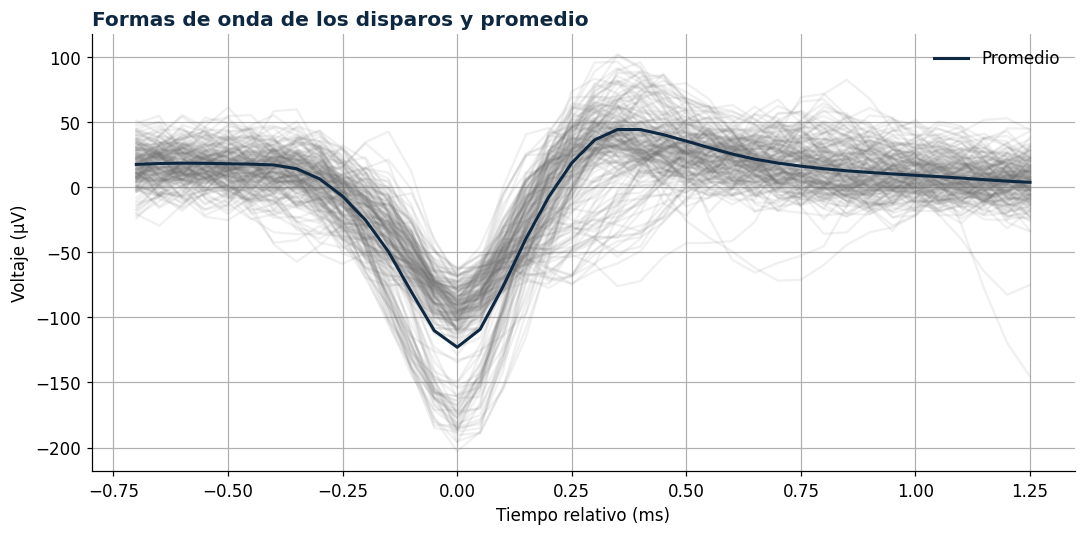

In [22]:
# Su código aquí.
# Al final debe quedar definida la matriz de formas:

pre_ms = 0.7
post_ms = 1.3

pre_samples = int(pre_ms * fs / 1000)
post_samples = int(post_ms * fs / 1000)
total_samples = pre_samples + post_samples


waveforms_list = []
valid_indices = []

for i in indices:

    start_sample = i - pre_samples
    end_sample = i + post_samples


    if start_sample >= 0 and end_sample <= len(AP):
        waveform = AP[start_sample:end_sample]
        waveforms_list.append(waveform)
        valid_indices.append(i)

formas = np.array(waveforms_list)

indices = np.array(valid_indices)
tiempos = indices / fs


plt.figure(figsize=(10, 5))


num_to_plot = min(200, formas.shape[0])


t_waveform = np.arange(-pre_ms, post_ms, 1000/fs)

t_waveform = t_waveform[:formas.shape[1]]

for j in range(num_to_plot):
    plt.plot(t_waveform, formas[j, :], color=GRAY, alpha=0.1)

plt.plot(t_waveform, formas.mean(axis=0), color=NAVY, lw=2, label="Promedio")

plt.xlabel("Tiempo relativo (ms)")
plt.ylabel("Voltaje (µV)")
plt.title("Formas de onda de los disparos y promedio", color=NAVY, fontweight="bold", loc="left")
plt.legend(frameon=False)
plt.grid(True)
plt.tight_layout()
plt.show()
# Si descartan los eventos de los bordes, descarten también su entrada en
# indices y en tiempos: de aquí en adelante los tres arreglos tienen que ir
# en el mismo orden y con el mismo tamaño.


In [23]:
# ✅ VERIFICACIÓN · ejercicio G1
n_esperado = int(0.002 * fs)
revisar("la ventana dura 2 ms",
        abs(formas.shape[1] - n_esperado) <= 1,
        "0,7 ms antes + 1,3 ms después = 2 ms = 40 muestras a 20 kHz")
revisar("hay una forma por disparo detectado (salvo los de los bordes)",
        len(indices) - 5 <= formas.shape[0] <= len(indices),
        "descarten solo los eventos cuya ventana se sale del registro")
revisar("el mínimo de la forma promedio cae dentro de la ventana, cerca del centro",
        0.2 < np.argmin(formas.mean(axis=0)) / formas.shape[1] < 0.6,
        "si el mínimo queda en el borde, la ventana está corrida: revisen el signo del desplazamiento")

  OK    la ventana dura 2 ms
  OK    hay una forma por disparo detectado (salvo los de los bordes)
  OK    el mínimo de la forma promedio cae dentro de la ventana, cerca del centro


parte h https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html

## H · Separar las tres unidades

En este registro hay **tres neuronas**. Su tarea es decidir, para cada disparo detectado, cuál de las tres lo produjo. Eso es *spike sorting*.

**El camino corto y su problema.** Lo primero que se le ocurre a cualquiera (y lo primero que va a proponer la IA) es separar por **amplitud**: los eventos grandes de una neurona, los pequeños de otra. Pruébenlo. Van a ver que funciona para una de las tres y que las otras dos quedan mezcladas.

**Lo que hace falta.** Dos disparos pueden tener la misma altura y venir de neuronas distintas, porque tienen **forma** distinta. Necesitan al menos una característica más, medida sobre las ventanas de la sección G. Algunas ideas:

- el **ancho** del valle a media altura (en ms);
- el tiempo entre el mínimo y el máximo de la onda;
- el área bajo la curva, o la pendiente de bajada.

*(Un tetrodo tiene cuatro electrodos exactamente por esto: la misma neurona vista desde cuatro sitios da cuatro amplitudes distintas, y esa combinación la identifica. Con un solo electrodo no tienen esa información, y por eso la forma es todo lo que les queda.)*

### ¿Qué es K-means?

**K-means** es un algoritmo que permite **agrupar datos que se parecen entre sí**. En este ejercicio, cada disparo se representa mediante las características que ustedes hayan elegido, por ejemplo, amplitud y ancho del valle.

El algoritmo intenta dividir los disparos en **K grupos** (*clusters*), de manera que los disparos dentro de un mismo grupo sean lo más parecidos posible. Como en este ejercicio sabemos que hay tres neuronas, utilizaremos **K = 3**.

De forma simplificada, K-means:

1. Coloca inicialmente **3 centros** (*centroides*) en el espacio de características.
2. Asigna cada disparo al centro más cercano.
3. Recalcula cada centro como el promedio de los disparos que tiene asignados.
4. Repite los pasos 2 y 3 hasta que los grupos se estabilizan.

**Importante:** K-means no sabe qué neurona corresponde a cada grupo. Si obtiene los grupos `0`, `1` y `2`, ustedes todavía tienen que determinar qué grupo corresponde a cada unidad.

### ✏️ Ejercicio H1 · Elegir dos características y agrupar

Elijan **dos** características, hagan un gráfico de dispersión de una contra otra, y miren si aparecen grupos (*clusters*). Si aparecen, agrúpenlos (a mano con umbrales, o con `KMeans` de `sklearn`) y asignen una etiqueta a cada disparo.

**Justifiquen su elección de características en la celda de texto.** Vale más eso que el acierto que saquen.

### Pedir ayuda a la IA

Antes de aplicar K-means, pídanle ayuda a una IA para entender **cómo se calcula cada una de las características que eligieron y qué pasos deben realizar antes de utilizar K-means**.

No se trata simplemente de pedirle a la IA que les dé el código completo. Utilícenla como asistente para comprender el análisis.

Por ejemplo, pueden preguntarle:

> ¿Cómo se calcula la amplitud de un spike a partir de una ventana de señal? Explícame paso a paso y dime qué unidades tiene el resultado.

> ¿Cómo puedo calcular el ancho del valle a media altura de un spike? Explícame qué puntos de la señal necesito identificar y cómo convertir el resultado a milisegundos?

> Tengo dos características para cada spike y quiero utilizar K-means. ¿Qué pasos debo hacer antes de aplicar K-means y por qué?

Como mínimo, averigüen y documenten:

- cómo se calcula **cada una de las dos características** que eligieron;
- qué unidades tiene cada característica;
- cómo convertir las medidas de muestras a unidades de tiempo cuando sea necesario;
- cómo organizar los datos para que cada **fila corresponda a un spike** y cada **columna a una característica**;
- si es necesario **escalar o normalizar las características antes de K-means**, y por qué;
- por qué deben utilizar **K = 3** en este ejercicio.

**En la celda de texto, expliquen con sus propias palabras qué aprendieron de la IA.** Si utilizan código sugerido por la IA, asegúrense de entender qué hace cada paso.

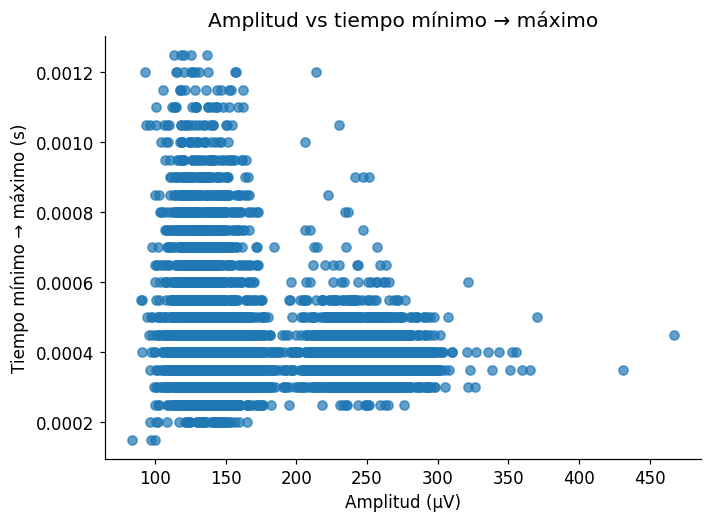

Número de spikes: 5463
Número de etiquetas: 5463
Etiquetas: [0 1 2]


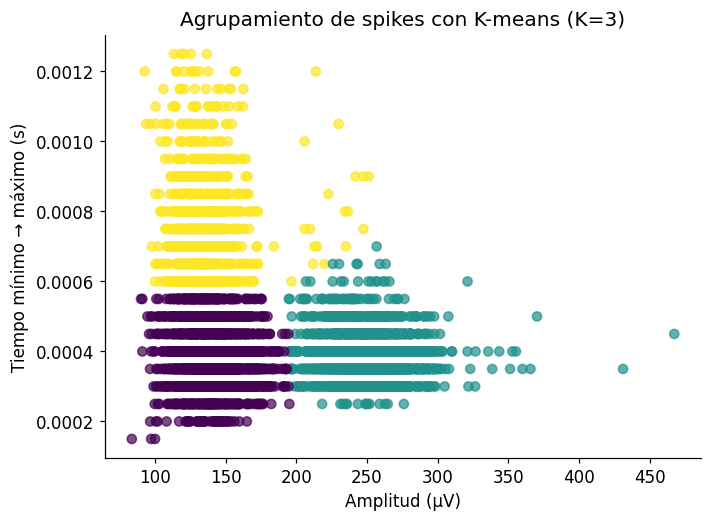

Clusters usando solo amplitud: [0 1 2]

Verificación de unidades usando solo amplitud:
  Spikes tuyos emparejados con uno real: 5459
  Unidades que propones: 3   ·   reales: 3

  Matriz de confusión (filas = tus unidades, columnas = reales)
                     U1       U2       U3
           2       1006       16        1
           0          3     2649      597
           1       1151       34        2

  Acierto   69.6%  ███████████████████·········

  ▸ La separación no funciona. ¿Sobre qué característica estás
    agrupando? ¿Basta con esa?
      Evento  Amplitud (µV)  Tiempo mínimo → máximo (s)  Cluster K-means  \
0          0     252.106442                     0.00035                1   
1          1     140.070709                     0.00070                2   
2          2     144.018297                     0.00030                0   
3          3     263.713466                     0.00035                1   
4          4     141.125512                     0.00065            

In [37]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import verificacion as v # Import the verification module

# --------------------------------------------------
# 1. Características de cada evento
# --------------------------------------------------

formas_para_caracteristicas = formas

amplitudes = []
tiempos_min_max = []

for forma in formas_para_caracteristicas:

    i_min = np.argmin(forma)
    i_max = np.argmax(forma)

    # Amplitud pico a pico
    amplitud = np.max(forma) - np.min(forma)

    # Tiempo entre mínimo y máximo
    tiempo = abs(i_max - i_min) / fs

    amplitudes.append(amplitud)
    tiempos_min_max.append(tiempo)

amplitudes = np.array(amplitudes)
tiempos_min_max = np.array(tiempos_min_max)

# --------------------------------------------------
# 2. Gráfico de dispersión
# --------------------------------------------------

plt.figure(figsize=(7,5))

plt.scatter(amplitudes, tiempos_min_max, alpha=0.7)

plt.xlabel("Amplitud (µV)")
plt.ylabel("Tiempo mínimo → máximo (s)")
plt.title("Amplitud vs tiempo mínimo → máximo")

plt.show()

# --------------------------------------------------
# 3. Organizar las características
# --------------------------------------------------

X = np.column_stack((amplitudes, tiempos_min_max))

# --------------------------------------------------
# 4. Escalar las características
# --------------------------------------------------

escalador = StandardScaler()
X_escalado = escalador.fit_transform(X)

# --------------------------------------------------
# 5. K-means con K = 3
# --------------------------------------------------

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

etiquetas = kmeans.fit_predict(X_escalado)

# --------------------------------------------------
# 6. Verificar
# --------------------------------------------------

print("Número de spikes:", len(X))
print("Número de etiquetas:", len(etiquetas))
print("Etiquetas:", np.unique(etiquetas))

plt.figure(figsize=(7,5))

plt.scatter(
    amplitudes,
    tiempos_min_max,
    c=etiquetas,
    alpha=0.7
)

plt.xlabel("Amplitud (µV)")
plt.ylabel("Tiempo mínimo → máximo (s)")
plt.title("Agrupamiento de spikes con K-means (K=3)")

plt.show()

# --------------------------------------------------
# 7. K-means usando SOLO amplitud
# --------------------------------------------------

X_amplitud = amplitudes.reshape(-1, 1)

# Escalar amplitud
X_amplitud_escalada = StandardScaler().fit_transform(X_amplitud)

# K-means con K = 3
kmeans_amplitud = KMeans(n_clusters=3, random_state=42, n_init=10)

etiquetas_amplitud = kmeans_amplitud.fit_predict(X_amplitud_escalada)

print("Clusters usando solo amplitud:", np.unique(etiquetas_amplitud))


# --------------------------------------------------
# 8. Comparar con las etiquetas reales
# --------------------------------------------------


print("\nVerificación de unidades usando solo amplitud:")
acierto_amplitud = v.verificar_unidades(tiempos, etiquetas_amplitud)

# --------------------------------------------------
# 9. Tabla con los valores de cada evento
# --------------------------------------------------

import pandas as pd

tabla = pd.DataFrame({
    "Evento": np.arange(len(amplitudes)),
    "Amplitud (µV)": amplitudes,
    "Tiempo mínimo → máximo (s)": tiempos_min_max,
    "Cluster K-means": etiquetas,
    "Cluster solo amplitud": etiquetas_amplitud
})

print(tabla)

In [25]:
# ✅ VERIFICACIÓN · ejercicio H1
acierto = v.verificar_unidades(indices / fs, etiquetas)

  Spikes tuyos emparejados con uno real: 5459
  Unidades que propones: 3   ·   reales: 3

  Matriz de confusión (filas = tus unidades, columnas = reales)
                     U1       U2       U3
           1       2137       30        3
           2          9      312      498
           0         14     2357       99

  Acierto   91.4%  ██████████████████████████··

  ▸ Separación correcta.


### ✏️ Ejercicio H2 · La matriz de confusión

La verificación les imprimió una **matriz de confusión**: filas = sus unidades, columnas =
las reales. Si dos de sus unidades se están mezclando, se ve como una fila repartida entre
dos columnas.

- ¿Cuáles se confunden y por qué?
- Repitan la agrupación usando **solo la amplitud** y comparen el acierto con el que
  obtuvieron con dos características. ¿Cuánto ganaron con la segunda?
- ¿Qué característica les habría separado mejor las dos que se mezclan?

**Nuestra lectura de la matriz:**

| | acierto |
|---|---|
| solo con amplitud | |
| con las dos características que elegimos | |

_Explicación:_ Se puede ver que tenemos confusión entre la detectada real de U3/U2, esto puede ser porque tanto la amplitud como el tiempo de min-max de la onda son similares entre si. Al usar amplitud solamente podemos ver como como el acierto baja a 69.6 comparado a cuando usamos dos condiciones. Otra caracteística que podría separar mejor sería el ancho de la banda, porque aunque tengan una amplitud similar tienen un ancho distinto por su forma temporal.


---
## I · El ISI como control de calidad

Ya tienen tres grupos. La verificación les dijo qué tan bien lo hicieron, pero **eso solo
existe con datos sintéticos**. Con un registro real nadie les va a decir el acierto:
necesitan una medida de calidad que se calcule **sin conocer la verdad**, y hay una que es
el estándar del oficio.

**El argumento.** Una neurona, después de disparar, no puede volver a disparar durante uno
o dos milisegundos: sus canales de sodio están inactivados. Es el **período refractario**, y
es biología, no convención. Entonces: si en el tren de una sola unidad aparecen intervalos
de menos de 2 ms, **esa unidad no es una neurona**. O son dos neuronas que su separación
fusionó, o el detector contó dos veces el mismo evento.

El intervalo entre disparos consecutivos se llama **ISI** (*inter-spike interval*), y la
fracción de ISI por debajo de 2 ms es la **tasa de violaciones del refractario**. En la
literatura se acepta una unidad por debajo del 0,5 a 1 %.

### ✏️ Ejercicio I1 · El ISI, junto y por unidad

**a)** Calculen el ISI de **todos** sus disparos juntos, sin separar por unidad, y la
fracción por debajo de 2 ms. Como aquí hay tres neuronas, ese número tiene que ser
claramente mayor que cero: es la prueba, **sin mirar la verdad**, de que ahí dentro hay más
de una neurona.

**b)** Ahora el ISI de **cada unidad por separado**. Si su separación es correcta, las tres
tasas deben caer cerca de cero. La que se quede alta está contaminada: tiene disparos de la
vecina.

**c)** Grafiquen el histograma de ISI de cada unidad, de 0 a 100 ms con bins de 1 ms, y
marquen los 2 ms con una línea vertical.

**d)** Vuelvan a hacer (a) y (b) con la detección de `muerto_ms = 0,4` del ejercicio F3.
¿Aparecen violaciones que antes no estaban? ¿De dónde salen?

Número de ISI: 5462
Fracción de ISI < 2 ms: 0.008238740388136214
Porcentaje de ISI < 2 ms: 0.8238740388136214 %
Unidad 0:
  Número de spikes: 2474
  Fracción ISI < 2 ms: 0.0004
  Porcentaje: 0.04%
Unidad 1:
  Número de spikes: 2170
  Fracción ISI < 2 ms: 0.0005
  Porcentaje: 0.05%
Unidad 2:
  Número de spikes: 819
  Fracción ISI < 2 ms: 0.0012
  Porcentaje: 0.12%


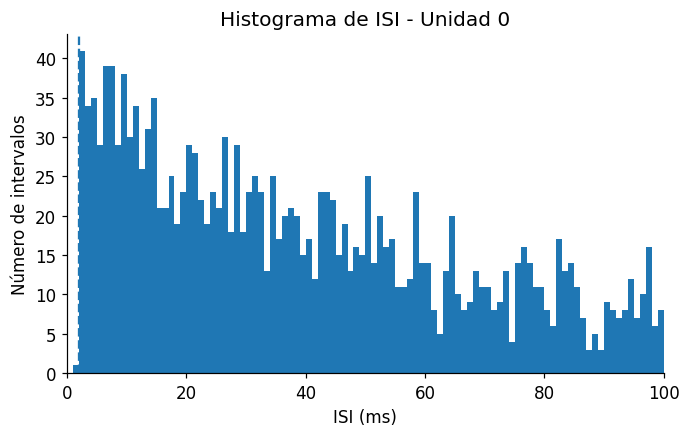

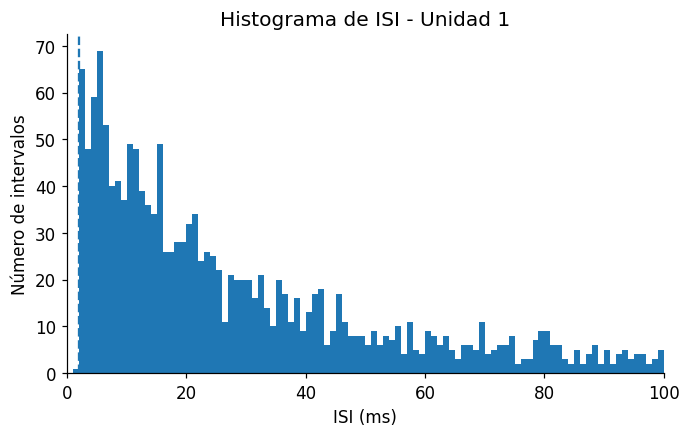

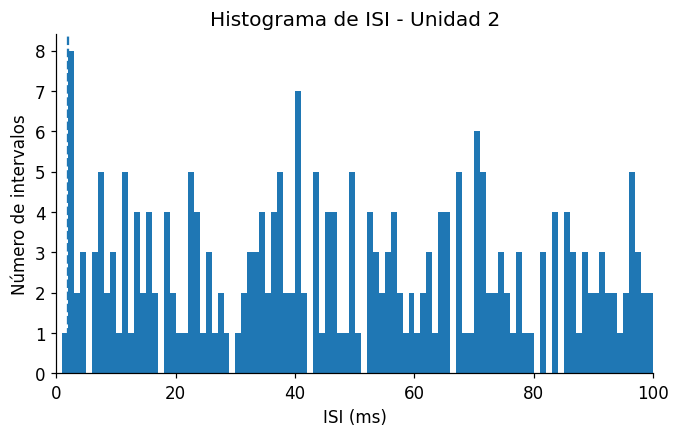

Con muerto_ms = 0.4 ms
Número de spikes: 5527
Fracción ISI < 2 ms: 0.020267824828085413
Porcentaje: 2.0267824828085415 %


In [26]:
# Su código aquí.
# ISI de todos los spikes juntos
#a
tiempos = np.sort(indices) / fs

isi_todos = np.diff(tiempos)

fraccion_menor_2ms = np.mean(isi_todos < 0.002)

print("Número de ISI:", len(isi_todos))
print("Fracción de ISI < 2 ms:", fraccion_menor_2ms)
print("Porcentaje de ISI < 2 ms:", fraccion_menor_2ms * 100, "%")

#b
for unidad in np.unique(etiquetas):

    tiempos_unidad = np.sort(tiempos[etiquetas == unidad])

    isi_unidad = np.diff(tiempos_unidad)

    fraccion = np.mean(isi_unidad < 0.002)

    print(f"Unidad {unidad}:")
    print(f"  Número de spikes: {len(tiempos_unidad)}")
    print(f"  Fracción ISI < 2 ms: {fraccion:.4f}")
    print(f"  Porcentaje: {fraccion * 100:.2f}%")

#c
for unidad in np.unique(etiquetas):

    tiempos_unidad = np.sort(tiempos[etiquetas == unidad])
    isi_unidad = np.diff(tiempos_unidad)

    # Pasar de segundos a milisegundos
    isi_ms = isi_unidad * 1000

    plt.figure(figsize=(7, 4))

    bins = np.arange(0, 101, 1)

    plt.hist(isi_ms, bins=bins)

    plt.axvline(2, linestyle="--")

    plt.xlabel("ISI (ms)")
    plt.ylabel("Número de intervalos")
    plt.title(f"Histograma de ISI - Unidad {unidad}")

    plt.xlim(0, 100)

    plt.show()

    #d
    muerto_ms = 0.4
    indices_04 = detectar_spikes(
    AP,
    fs,
    muerto_ms=0.4
)
    tiempos_04 = np.sort(indices_04) / fs

isi_todos_04 = np.diff(tiempos_04)

fraccion_04 = np.mean(isi_todos_04 < 0.002)

print("Con muerto_ms = 0.4 ms")
print("Número de spikes:", len(indices_04))
print("Fracción ISI < 2 ms:", fraccion_04)
print("Porcentaje:", fraccion_04 * 100, "%")


**Nuestra lectura del ISI:**

| | violaciones < 2 ms |
|---|---|
| todos los disparos juntos | |
| unidad 1 | |
| unidad 2 | |
| unidad 3 | |

¿Alguna unidad está contaminada? ¿Cuál y por qué?

¿Qué pasó al bajar el período muerto a 0,4 ms?

Respuesta: La uniadad 2 es la más contaminada con 0.12, porque tiene mayor proporcion de spikes menores a 2ms. Si lo bajamos a 0.4 aceptaría más eventos cercanos lo que aumentaria el ISI, en otras palabras, habría más contaminaciones.


---
# Segunda parte · Del tren de disparos a la figura

Hasta aquí convirtieron un archivo de voltaje en una lista de disparos con su neurona
asignada. Esa lista, por sí sola, no dice nada: es una columna de números.

Ahora la convierten en la respuesta a una pregunta: **¿cuál de las tres neuronas responde a
qué estímulo?**

Todo lo que sigue (el raster, el PSTH, el ISI, el heatmap) son cuatro maneras distintas de
mirar exactamente el mismo dato: una lista de instantes. Parte del ejercicio es entender
qué se gana y qué se pierde en cada una, y terminar armando **una figura** que las junte.

---
## J · Leer el protocolo experimental

El grupo `estimulos` dice cuándo ocurrió cada ensayo y qué se presentó. Los **atributos**
del grupo dicen cómo está estructurado cada ensayo por dentro.

### ✏️ Ejercicio J1 · Explorar el grupo estimulos

Cárguenlo y contesten, **con código**:

- ¿Cuántos ensayos hay y cuántos por condición?
- ¿Cuánto dura un ensayo? ¿Cuándo empieza el estímulo dentro del ensayo?
- ¿Están las condiciones en orden o intercaladas? **¿Por qué importa eso?**

In [27]:
# Su código aquí.
# Pista: with h5py.File(ARCHIVO, "r") as f: ... y no olviden f["estimulos"].attrs
import h5py
import numpy as np

with h5py.File(ARCHIVO, "r") as f:
    estimulos = f["estimulos"]

    inicios = estimulos["tiempo_inicio_s"][:]
    condiciones = estimulos["condicion"][:]

    t_pre = estimulos.attrs["duracion_pre_s"]
    t_est = estimulos.attrs["duracion_estimulo_s"]
    t_post = estimulos.attrs["duracion_post_s"]


condiciones_str = np.array([c.decode('utf-8') for c in condiciones])


# 1. ¿Cuántos ensayos hay y cuántos por condición?
num_ensayos = len(inicios)
unique_conds, counts_conds = np.unique(condiciones_str, return_counts=True)

print(f"Número total de ensayos: {num_ensayos}")
print("Número de ensayos por condición:")
for cond, count in zip(unique_conds, counts_conds):
    print(f"  Condición '{cond}': {count} ensayos")

# 2. ¿Cuánto dura un ensayo? ¿Cuándo empieza el estímulo dentro del ensayo?
duracion_ensayo = t_pre + t_est + t_post

print(f"\nDuración total de un ensayo: {duracion_ensayo:.1f} s")
print(f"El estímulo empieza {t_pre:.1f} s después del inicio del ensayo.")
print(f"Duración del pre-estímulo: {t_pre:.1f} s")
print(f"Duración del estímulo: {t_est:.1f} s")
print(f"Duración del post-estímulo: {t_post:.1f} s")

# 3. ¿Están las condiciones en orden o intercaladas? ¿Por qué importa eso?
# Check if the first few conditions are different
is_intercalated = len(np.unique(condiciones_str[:5])) > 1

if is_intercalated:
    print("\nLas condiciones de estímulo están intercaladas.")
    print("Esto es importante porque evita efectos de habituación o fatiga que podrían sesgar los resultados si los estímulos se presentaran en bloques consecutivos.")
else:
    print("\nLas condiciones de estímulo están en orden (no intercaladas).")
    print("Esto podría introducir sesgos debido a efectos de habituación o fatiga.")


inicios = inicios # instante de inicio de cada ENSAYO, en segundos
condiciones = condiciones # la condición de cada ensayo ('A', 'B' o 'C')
t_pre = t_pre # cuánto dura el pre-estímulo dentro del ensayo, en segundos
t_est = t_est  # cuánto dura el estímulo, en segundos

Número total de ensayos: 60
Número de ensayos por condición:
  Condición 'A': 20 ensayos
  Condición 'B': 20 ensayos
  Condición 'C': 20 ensayos

Duración total de un ensayo: 3.0 s
El estímulo empieza 1.0 s después del inicio del ensayo.
Duración del pre-estímulo: 1.0 s
Duración del estímulo: 0.5 s
Duración del post-estímulo: 1.5 s

Las condiciones de estímulo están intercaladas.
Esto es importante porque evita efectos de habituación o fatiga que podrían sesgar los resultados si los estímulos se presentaran en bloques consecutivos.


In [28]:
# ✅ VERIFICACIÓN · ejercicio J1
revisar("hay un inicio por ensayo y una condición por ensayo",
        len(inicios) == len(condiciones) and len(inicios) > 30)
revisar("las condiciones están intercaladas, no en bloques",
        len(set(np.asarray(condiciones)[:6].tolist())) > 1,
        "si les salen las primeras seis iguales, están leyendo mal el arreglo")
revisar("el pre-estímulo y el estímulo son positivos y menores que el ensayo",
        0 < t_est < t_pre + t_est < 5)
revisar("los ensayos no se solapan",
        bool(np.all(np.diff(np.sort(inicios)) >= t_pre + t_est)))

  OK    hay un inicio por ensayo y una condición por ensayo
  OK    las condiciones están intercaladas, no en bloques
  OK    el pre-estímulo y el estímulo son positivos y menores que el ensayo
  OK    los ensayos no se solapan


---
## K · De tiempo absoluto a tiempo relativo ·

Sus disparos están en tiempo absoluto: segundos desde que empezó el registro. Para comparar
ensayos entre sí eso no sirve, porque cada ensayo ocurrió en un momento distinto.

Lo que necesitan es, para cada ensayo, los disparos expresados **en tiempo relativo al
estímulo**: negativos antes de que empezara, cero justo cuando empieza, positivos después.

### ✏️ Ejercicio K1 · La función alinear()

**Especificación:**

```
alinear(tiempos, inicios, t_pre, ventana=(-1.0, 2.0)) -> lista de arreglos, uno por ensayo
```

⚠️ **Ojo con esto:** `inicios` marca el comienzo del **ensayo**, no el del **estímulo**. El
estímulo empieza `t_pre` segundos después. Si se saltan ese detalle, todo lo que viene
queda corrido un segundo y **los gráficos van a salir perfectamente creíbles**. Ese es el
problema: no hay error, no hay aviso, solo una conclusión equivocada.

### ✏️ Ejercicio K2 · La comprobación a mano

Comprueben a mano un ensayo cualquiera: tomen sus disparos
absolutos, réstenles el instante del estímulo y verifiquen que coinciden con lo que
devuelve su función.

In [29]:
def alinear(tiempos, inicios, t_pre, ventana=(-1.0, 2.0)):
    """Devuelve una lista con un arreglo de tiempos relativos al estímulo por ensayo."""
    # Su código aquí.

    resultados = []

    for inicio_ensayo in inicios:

        inicio_estimulo = inicio_ensayo + t_pre

        # Límites de la ventana respecto al estímulo
        limite_inferior = inicio_estimulo + ventana[0]
        limite_superior = inicio_estimulo + ventana[1]

        # Disparos dentro de la ventana
        disparos = tiempos[
            (tiempos >= limite_inferior) &
            (tiempos <= limite_superior)
        ]

        # Convertir a tiempo relativo al estímulo
        disparos_relativos = disparos - inicio_estimulo

        resultados.append(disparos_relativos)

    return resultados


# Un diccionario con los ensayos alineados de cada unidad, para usar de aquí en adelante
etiquetas = np.asarray(etiquetas)     # por si quedaron en una lista
alineados = {u: alinear(tiempos[etiquetas == u], inicios, t_pre) for u in np.unique(etiquetas)}

In [30]:
import numpy as np

# Elijan un ensayo para verificar, por ejemplo el primer ensayo (índice 0)
trial_idx = 0

# Obtener el inicio absoluto del estímulo para este ensayo
# Recordar que `inicios` es el inicio del ENSAYO, y el estímulo empieza `t_pre` segundos después.
stim_onset_abs = inicios[trial_idx] + t_pre

# Definir la ventana que se usó en la función alinear (por defecto es (-1.0, 2.0))
ventana = (-1.0, 2.0)
limite_inferior_abs = stim_onset_abs + ventana[0]
limite_superior_abs = stim_onset_abs + ventana[1]

u0 = np.unique(etiquetas)[0]

# Obtener solo los tiempos de las espigas que pertenecen a la unidad u0
spikes_de_unidad_u0 = tiempos[etiquetas == u0]

# 1. Obtener manualmente los spikes relativos para este ensayo
# Filtrar los spikes de la unidad `u0` que caen dentro de la ventana de este ensayo
spikes_en_ensayo_manual = spikes_de_unidad_u0[
    (spikes_de_unidad_u0 >= limite_inferior_abs) &
    (spikes_de_unidad_u0 <= limite_superior_abs)
]
# Convertirlos a tiempos relativos al inicio del estímulo
spikes_relativos_manual = spikes_en_ensayo_manual - stim_onset_abs

# 2. Obtener los spikes relativos usando la función `alinear()`
# Para un ensayo específico de una unidad (por ejemplo, unidad 0)
# `alineados` es un diccionario donde cada clave es una unidad y el valor es una lista de arrays (uno por ensayo)
# Aquí seleccionamos la lista de arrays para la primera unidad (u0) y luego el array correspondiente al `trial_idx`
spikes_relativos_funcion = alineados[u0][trial_idx] # Suponiendo que `alineados` ya fue calculado

# 3. Comparar los resultados
print(f"Verificando el ensayo {trial_idx + 1} (Unidad {u0}):")
print(f"  Inicio absoluto del estímulo: {stim_onset_abs:.3f} s")
print(f"  Spikes relativos (manual): {np.round(spikes_relativos_manual, 3)}")
print(f"  Spikes relativos (función alinear): {np.round(spikes_relativos_funcion, 3)}")

# Imprimir las longitudes de los arrays para depuración
print(f"  Longitud spikes_relativos_manual: {len(spikes_relativos_manual)}")
print(f"  Longitud spikes_relativos_funcion: {len(spikes_relativos_funcion)}")

# Comprobación numérica: ordenar y comparar los arrays
is_equal = np.allclose(np.sort(spikes_relativos_manual), np.sort(spikes_relativos_funcion))
print(f"  ¿Coinciden los resultados manuales y de la función?: {is_equal}")

# Si no coinciden, pueden imprimir la diferencia o revisar más a fondo
if not is_equal:
    print("  Diferencia detectada. Revisa tu implementación de `alinear()`.")


Verificando el ensayo 1 (Unidad 0):
  Inicio absoluto del estímulo: 31.000 s
  Spikes relativos (manual): [-1.    -0.93  -0.895 -0.873 -0.855 -0.828 -0.798 -0.61  -0.477 -0.236
 -0.179 -0.176 -0.162 -0.065  0.002  0.072  0.123  0.126  0.153  0.192
  0.232  0.248  0.276  0.291  0.301  0.304  0.316  0.341  0.352  0.359
  0.409  0.415  0.436  0.589  0.638  0.659  0.667  0.76   0.779  0.827
  0.873  0.985  1.098  1.246  1.287  1.411  1.422  1.459  1.578  1.59
  1.634  1.71   1.819  1.975]
  Spikes relativos (función alinear): [-1.    -0.93  -0.895 -0.873 -0.855 -0.828 -0.798 -0.61  -0.477 -0.236
 -0.179 -0.176 -0.162 -0.065  0.002  0.072  0.123  0.126  0.153  0.192
  0.232  0.248  0.276  0.291  0.301  0.304  0.316  0.341  0.352  0.359
  0.409  0.415  0.436  0.589  0.638  0.659  0.667  0.76   0.779  0.827
  0.873  0.985  1.098  1.246  1.287  1.411  1.422  1.459  1.578  1.59
  1.634  1.71   1.819  1.975]
  Longitud spikes_relativos_manual: 54
  Longitud spikes_relativos_funcion: 54
  ¿Coinci

In [31]:
# ✅ VERIFICACIÓN · ejercicios K1 y K2
u0 = np.unique(etiquetas)[0]
todos = np.concatenate(alineados[u0])
revisar("hay una lista de disparos por ensayo",
        len(alineados[u0]) == len(inicios))
revisar("todos los tiempos caen dentro de la ventana pedida",
        bool(np.all((todos >= -1.0) & (todos <= 2.0))),
        "hay que recortar cada ensayo a la ventana, no solo restar")
revisar("hay disparos antes del estímulo (tiempos negativos)",
        bool(np.any(todos < 0)),
        "la ventana empieza 1 s ANTES del estímulo: si no hay negativos, están recortando mal")
revisar("la ventana está completa en todos los ensayos",
        min(len(e) for e in alineados[u0]) >= 0 and float(todos.max()) > 1.5)

# Ojo: ninguna de estas comprobaciones puede decirles si alinearon al ensayo o al
# estímulo. Las dos versiones pasan. La única que lo detecta es la comprobación a
# mano de la celda anterior, y por eso está en la rúbrica.

  OK    hay una lista de disparos por ensayo
  OK    todos los tiempos caen dentro de la ventana pedida
  OK    hay disparos antes del estímulo (tiempos negativos)
  OK    la ventana está completa en todos los ensayos


---
## L · Raster

Un raster es el gráfico más honesto que existe en electrofisiología: **un punto por
disparo**, sin promediar nada. Cada fila es un ensayo, el eje horizontal es el tiempo
relativo al estímulo.

### ✏️ Ejercicio L1 · Los tres paneles del raster

Hagan una figura con **tres paneles, uno por unidad**. Dentro de cada panel agrupen los
ensayos por condición y sepárenlos visualmente (colores distintos, o bloques separados) y
marquen con una banda sombreada la ventana en que estuvo presente el estímulo.

**Pregunta L2.** Miren el resultado y contesten, **antes de calcular nada**:

- ¿Qué unidad responde al estímulo y cuál no?
- ¿Alguna responde solo a una de las tres condiciones?
- ¿Se ve la respuesta en **todos** los ensayos o solo en algunos?

*Pista de diseño: `plt.eventplot` hace esto en una línea, pero configurar los colores por
condición requiere pensar. También se puede a mano con `plt.scatter` y algo de aritmética
sobre el índice de fila.*

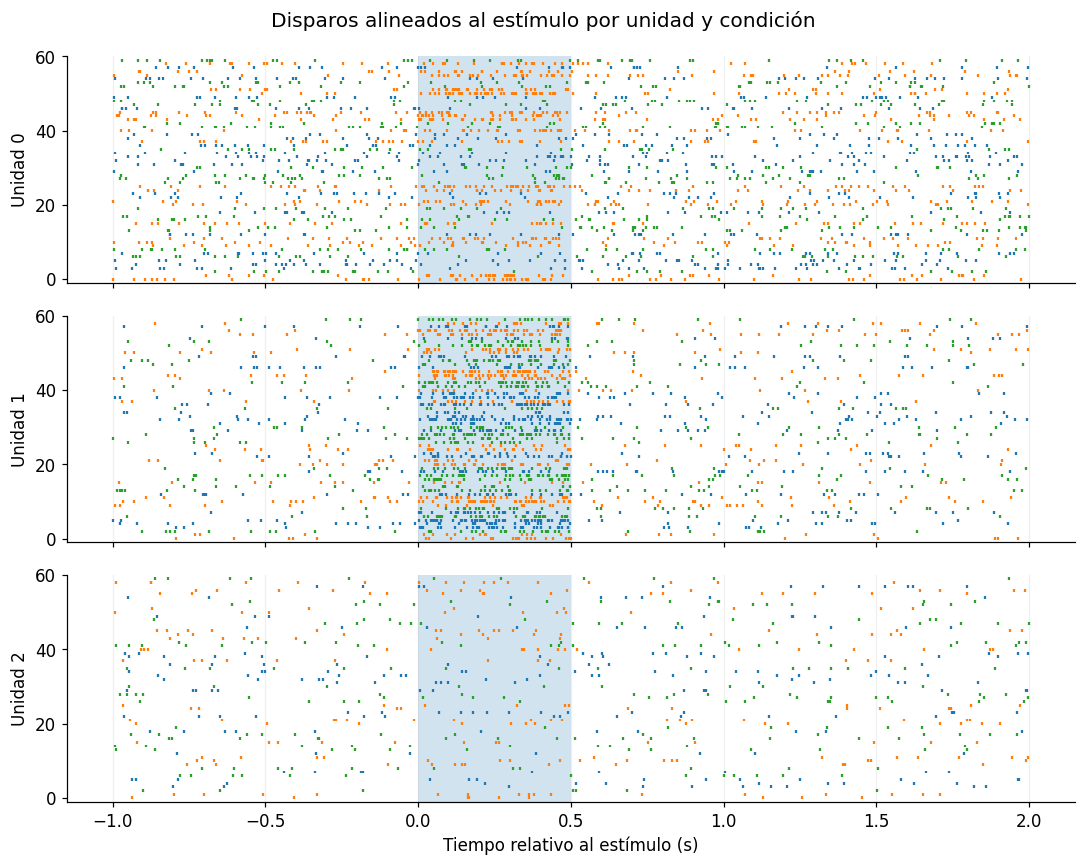

In [32]:
# Su código aquí.
import numpy as np
import matplotlib.pyplot as plt

unidades = np.unique(etiquetas)

fig, axes = plt.subplots(
    3, 1,
    figsize=(10, 8),
    sharex=True
)

# Colores para las condiciones
colores = {
    "A": "tab:blue",
    "B": "tab:orange",
    "C": "tab:green"
}

for ax, unidad in zip(axes, unidades):

    # Ensayos de esta unidad
    ensayos = alineados[unidad]

    for i, (spikes, condicion) in enumerate(zip(ensayos, condiciones)):

        # Dibujar cada spike como una línea vertical
        for spike in spikes:
            ax.vlines(
                spike,
                i - 0.4,
                i + 0.4,
                color=colores[condicion.decode('utf-8')] # Decode byte string to regular string
            )

    # Banda donde estuvo presente el estímulo
    ax.axvspan(
        0,
        t_est,
        alpha=0.2
    )

    ax.set_ylabel(f"Unidad {unidad}")

    ax.set_ylim(-1, len(ensayos))

    ax.grid(axis="x", alpha=0.2)

axes[-1].set_xlabel("Tiempo relativo al estímulo (s)")

plt.suptitle("Disparos alineados al estímulo por unidad y condición")

plt.tight_layout()
plt.show()

**Lo que leemos en el raster:**

En la unidad 1 del medio, se puede observar que es la que más claramente responde al estímulo, porque se ve que durante la ventana de 0 a 0,5 s hay una mayor concentración de disparos. En cambio, las unidades 0 y 2, se ven más dispersas y no muestran un cambio muy evidente. La unidad 1 parece responder en las 3 condiciones, aunque no con la misma intensidad en todos los ensayos. No todos los ensayos presentan exactamente el mismo nivel de repuesta, pero si observa una mayor concentración de disparos la ventana del estímulo.



---
## M · PSTH y el problema del bin

El PSTH (*peri-stimulus time histogram*) es el promedio de todos los ensayos: cuenta
cuántos disparos cayeron en cada intervalo de tiempo y lo convierte en **tasa de disparo**,
en disparos por segundo.

### ✏️ Ejercicio M1 · La función psth()

Escriban la función:

```
psth(ensayos_alineados, ventana, ancho_bin_s) -> (centros_de_bin, tasa_Hz)
```

Cuidado con las unidades: si cuentan disparos por bin y dividen por el número de ensayos,
tienen disparos por ensayo, **no Hz**. Falta un paso.

### ✏️ Ejercicio M2 · PSTH por unidad y condición

Grafiquen el PSTH de cada unidad y cada condición.

### ✏️ Ejercicio M3 · El efecto del bin (la parte importante)

Tomen la unidad que responde y grafiquen su PSTH con cuatro
anchos de bin: **5, 20, 50 y 200 ms**, los cuatro paneles juntos y con el mismo eje y.

Contesten: **¿cuál elegirían para una figura de un artículo, y qué información pierde cada
uno de los otros tres?** Fíjense en que con el bin más ancho la respuesta parece más
pequeña de lo que es. ¿Por qué?

In [33]:
def psth(ensayos_alineados, ventana, ancho_bin_s):
    """Devuelve (centros_de_bin, tasa_en_Hz)."""
    # Su código aquí.
    import numpy as np

def psth(ensayos_alineados, ventana, ancho_bin_s):
    """
    Calcula el PSTH a partir de los disparos alineados de varios ensayos.

    Parámetros
    ----------
    ensayos_alineados : lista de arrays
        Cada elemento contiene los tiempos de los spikes de un ensayo.
    ventana : tuple
        (inicio, final) en segundos.
    ancho_bin_s : float
        Ancho de cada bin en segundos.

    Retorna
    -------
    centros_de_bin : array
        Centro de cada bin, en segundos.
    tasa_Hz : array
        Tasa de disparo en Hz.
    """

    # Crear los bordes de los bins
    bordes = np.arange(
        ventana[0],
        ventana[1] + ancho_bin_s,
        ancho_bin_s
    )

    # Contar todos los spikes de todos los ensayos
    todos_los_spikes = np.concatenate(ensayos_alineados)

    conteos, _ = np.histogram(
        todos_los_spikes,
        bins=bordes
    )

    # Número de ensayos
    n_ensayos = len(ensayos_alineados)

    # Convertir conteos a tasa en Hz
    tasa_Hz = conteos / (n_ensayos * ancho_bin_s)

    # Centro de cada bin
    centros_de_bin = (bordes[:-1] + bordes[1:]) / 2

    return centros_de_bin, tasa_Hz


    ...

In [34]:
# ✅ VERIFICACIÓN · ejercicio M1
u_ej = np.unique(etiquetas)[0]
c_, r_ = psth(alineados[u_ej], (-1.0, 2.0), 0.02)
n_disp = sum(len(e) for e in alineados[u_ej])
revisar("devuelve dos arrays del mismo tamaño", len(c_) == len(r_))
revisar("hay 150 bins de 20 ms en una ventana de 3 s", len(c_) == 150,
        "la ventana va de -1 a 2 s: son 3 s en total")
revisar("los centros de bin están dentro de la ventana",
        c_.min() > -1.0 and c_.max() < 2.0,
        "los centros van desplazados medio bin respecto a los bordes")
revisar("la tasa está en Hz, no en disparos por bin",
        abs(r_.mean() - n_disp/len(alineados[u_ej])/3.0) < 1.0,
        "cuentas / (n_ensayos * ancho_bin) = Hz. Si les da 50 veces menos, les falta dividir por el ancho")

  OK    devuelve dos arrays del mismo tamaño
  OK    hay 150 bins de 20 ms en una ventana de 3 s
  OK    los centros de bin están dentro de la ventana
  OK    la tasa está en Hz, no en disparos por bin


In [35]:
# Ejercicios M2 y M3: su código aquí.
ventana = (-1.0, 2.0)
ancho_bin = 0.02   # 20 ms

for unidad in np.unique(etiquetas):

    plt.figure(figsize=(9, 5))

    for condicion in np.unique(condiciones_texto):

        # Seleccionar los ensayos de esta condición
        ensayos_condicion = [
            ensayo
            for ensayo, cond in zip(alineados[unidad], condiciones_texto)
            if cond == condicion
        ]

        centros, tasa = psth(
            ensayos_condicion,
            ventana,
            ancho_bin
        )

        plt.plot(
            centros,
            tasa,
            label=f"Condición {condicion}"
        )

    # Ventana del estímulo
    plt.axvspan(
        0,
        t_est,
        alpha=0.2
    )

    plt.axvline(0, linestyle="--", alpha=0.5)

    plt.xlabel("Tiempo relativo al estímulo (s)")
    plt.ylabel("Tasa de disparo (Hz)")
    plt.title(f"PSTH — Unidad {unidad}")
    plt.legend()
    plt.grid(alpha=0.2)

    plt.show()

    # Definimos la unidad_responde aquí para el ejercicio M3, basándonos en la inspección visual del raster.
    # Unidad 1 mostró una clara respuesta excitatoria.
    unidad_responde = 1

    anchos = [0.005, 0.020, 0.050, 0.200]

fig, axes = plt.subplots(
    2, 2,
    figsize=(12, 8),
    sharex=True,
    sharey=True
)

for ax, ancho_bin in zip(axes.ravel(), anchos):

    for condicion in np.unique(condiciones_texto):

        ensayos_condicion = [
            ensayo
            for ensayo, cond in zip(
                alineados[unidad_responde],
                condiciones_texto
            )
            if cond == condicion
        ]

        centros, tasa = psth(
            ensayos_condicion,
            (-1.0, 2.0),
            ancho_bin
        )

        ax.plot(
            centros,
            tasa,
            label=f"Condición {condicion}"
        )

    ax.axvspan(
        0,
        t_est,
        alpha=0.2
    )

    ax.axvline(
        0,
        linestyle="--",
        alpha=0.5
    )

    ax.set_title(f"Bin = {ancho_bin * 1000:.0f} ms")
    ax.set_xlabel("Tiempo relativo al estímulo (s)")
    ax.set_ylabel("Tasa (Hz)")
    ax.grid(alpha=0.2)

# Una sola leyenda
axes[0, 0].legend()

plt.suptitle(
    f"Efecto del ancho del bin — Unidad {unidad_responde}"
)

plt.tight_layout()
plt.show()

NameError: name 'condiciones_texto' is not defined

<Figure size 990x550 with 0 Axes>

**Nuestra elección de bin y por qué:**
Elegríamos el bin de 20 ms dado que tiene un buen equilibrio entre resolución temporal y estabilidad de la gráfica. Con el bin de 5 ms se  pueden observar más detalles, pero el PSTH es mucho más ruidoso. En el bin de 50 ms y el de 200 ms (especialmente esta) la curva se suaviza demasiado y se pierde información del momento exacto de respuesta.

| ancho de bin | pico del PSTH (Hz) | qué se ve · qué se pierde |
|---|---|---|
| 5 ms | | |
| 20 ms | | |
| 50 ms | | |
| 200 ms | | |

---
## N · Heatmap multiunidad

El raster muestra ensayo por ensayo y el PSTH promedia. El heatmap junta las dos cosas:
cada fila es un PSTH, y el color es la tasa de disparo.

### ✏️ Ejercicio N1 · El heatmap multiunidad

Hagan uno que muestre **todas las unidades a la vez**:

- **Filas:** una por cada combinación de unidad y condición (3 × 3 = **nueve filas**),
  agrupadas por unidad.
- **Columnas:** tiempo relativo al estímulo, con el bin que eligieron en la sección M.
- **Color:** la tasa de disparo en Hz, promediada sobre los ensayos de esa condición.

Tres decisiones que hay que tomar **y justificar**:

1. **La escala de color, ¿compartida o por fila?** Si es compartida, se pueden comparar
   unidades entre sí, pero la más callada se ve negra y no se le distingue nada. Si es por
   fila, cada una se ve bien pero ya no son comparables. Elijan una y digan qué pierden.
   *(Si normalizan por fila, dejen de rotular la barra en Hz: ya no son Hz.)*
2. **Barra de color con su unidad.** Un heatmap sin barra de color no significa nada. Y un
   mapa **secuencial** (`viridis`, `magma`), no uno divergente como `jet`: busquen por qué
   `jet` está desaconsejado en publicación científica y digan en una línea qué encontraron.
3. **Una línea vertical en t = 0** y la ventana del estímulo marcada, para que la figura se
   pueda leer sin el pie.

**Pregunta N2.** Miren la figura terminada y contesten: **¿se lee ahí, sin ayuda de nada más, cuál neurona
responde a qué?** Esa es la prueba de una buena figura.

In [ ]:
# Su código aquí.
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------
# Parámetros
# ---------------------------------------------

ventana = (-1.0, 2.0)

# Usa aquí el ancho de bin que elegiste en M
ancho_bin_s = 0.020   # 20 ms

# Convertir condiciones b'A' -> 'A'
condiciones_texto = np.array([
    c.decode() if isinstance(c, bytes) else c
    for c in condiciones
])

unidades = np.unique(etiquetas)
condiciones_unicas = np.unique(condiciones_texto)

# ---------------------------------------------
# Calcular todos los PSTH
# ---------------------------------------------

filas = []
nombres_filas = []

for unidad in unidades:

    for condicion in condiciones_unicas:

        # Ensayos de esta unidad y condición
        ensayos_condicion = [
            ensayo
            for ensayo, cond in zip(
                alineados[unidad],
                condiciones_texto
            )
            if cond == condicion
        ]

        centros, tasa = psth(
            ensayos_condicion,
            ventana,
            ancho_bin_s
        )

        filas.append(tasa)
        nombres_filas.append(f"Unidad {unidad} - {condicion}")

# Convertir a matriz
heatmap = np.array(filas)

# ---------------------------------------------
# Gráfico
# ---------------------------------------------

fig, ax = plt.subplots(figsize=(11, 6))

im = ax.imshow(
    heatmap,
    aspect="auto",
    origin="upper",
    extent=[
        centros[0] - ancho_bin_s / 2,
        centros[-1] + ancho_bin_s / 2,
        len(nombres_filas),
        0
    ],
    cmap="viridis"
)

# Línea en el comienzo del estímulo
ax.axvline(
    0,
    linestyle="--",
    linewidth=1.5
)

# Ventana donde está presente el estímulo
ax.axvspan(
    0,
    t_est,
    alpha=0.15
)

# ---------------------------------------------
# Ejes
# ---------------------------------------------

ax.set_yticks(np.arange(len(nombres_filas)) + 0.5)
ax.set_yticklabels(nombres_filas)

ax.set_xlabel("Tiempo relativo al estímulo (s)")
ax.set_ylabel("Unidad y condición")

ax.set_title("PSTH multiunidad por condición")

# Barra de color
cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Tasa de disparo (Hz)")

plt.tight_layout()
plt.show()

**Lo que el heatmap muestra y el PSTH escondía:**
En el heatmap se puede ver qué neurona responde a qué condición. Se observa que la unidad 0 responde principalmente a la condición B, mientras que la unidad 1 presenta respuesta en las 3 condiciones. La unidad 2 no muestra una respuesta clara. El heatmap permite porque cada fila corresponde a una cobinación de unidad y condición y el color representa la tasa de disparo. Además, a diferencia del PSTH, donde varias condiciones aparecen como curvas y pueden esconder algunas diferencias, aquí se pueden comparar directamente las condiciones de cada unidad.

---
## O · La figura final · **evaluado**

Todo lo anterior fueron figuras de trabajo: sirven para entender, no para publicar. Ahora
armen **una sola figura** que resuma el taller entero y se defienda sola, como la que irá
en su póster del proyecto final.

### ✏️ Ejercicio O1 · La figura de cuatro paneles

| Panel | Contenido |
|---|---|
| **A** | las tres formas promedio, una por unidad, superpuestas y en la misma escala (la evidencia de que son tres neuronas distintas) |
| **B** | el raster de la unidad que responde, con los ensayos agrupados por condición |
| **C** | el PSTH de esa misma unidad, debajo del raster y **con el mismo eje x**, alineados |
| **D** | el heatmap multiunidad de la sección N |

**Reglas de figura científica**, y aquí sí se evalúan una por una:

- Todos los ejes con nombre **y unidad**.
- Los paneles rotulados **A, B, C, D**, arriba a la izquierda.
- B y C comparten el eje x, y se nota: las marcas de tiempo se corresponden.
- El instante del estímulo marcado en los tres paneles temporales, de la misma manera.
- Nada de texto ilegible: si al exportar a PNG no se puede leer una etiqueta, no sirve.
- Un **pie de figura** de tres o cuatro líneas, en la celda de texto de abajo. Que describa
  lo que se ve, no lo que ustedes concluyen. Miren cómo está escrito el pie de cualquier
  figura de los artículos del journal club.

Guárdenla con `plt.savefig("figuras/figura_final.png", dpi=200, bbox_inches="tight")`.

*Pista: `plt.subplots` con `gridspec_kw={"height_ratios": [...]}` y `sharex=True` para B y C.*

In [ ]:
# Su código aquí.
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

# Definición de la función psth (movida aquí para resolver NameError)
def psth(ensayos_alineados, ventana, ancho_bin_s):
    """
    Calcula el PSTH a partir de los disparos alineados de varios ensayos.

    Parámetros
    ----------
    ensayos_alineados : lista de arrays
        Cada elemento contiene los tiempos de los spikes de un ensayo.
    ventana : tuple
        (inicio, final) en segundos.
    ancho_bin_s : float
        Ancho de cada bin en segundos.

    Retorna
    -------
    centros_de_bin : array
        Centro de cada bin, en segundos.
    tasa_Hz : array
        Tasa de disparo en Hz.
    """

    # Crear los bordes de los bins
    bordes = np.arange(
        ventana[0],
        ventana[1] + ancho_bin_s,
        ancho_bin_s
    )

    # Contar todos los spikes de todos los ensayos
    todos_los_spikes = np.concatenate(ensayos_alineados)

    conteos, _ = np.histogram(
        todos_los_spikes,
        bins=bordes
    )

    # Número de ensayos
    n_ensayos = len(ensayos_alineados)

    # Convertir conteos a tasa en Hz
    tasa_Hz = conteos / (n_ensayos * ancho_bin_s)

    # Centro de cada bin
    centros_de_bin = (bordes[:-1] + bordes[1:]) / 2

    return centros_de_bin, tasa_Hz

# Responsive unit identified from previous exercises (Unit 1)
responsive_unit = 1

# Define colors for conditions for consistency
cond_colors = {
    "A": "tab:blue",
    "B": "tab:orange",
    "C": "tab:green"
}

# --- Figure Setup ---
fig = plt.figure(figsize=(15, 12))
gs = GridSpec(2, 2, figure=fig, height_ratios=[1, 1])

# Panel A: Waveforms (Top-Left)
axA = fig.add_subplot(gs[0, 0])
# Panel D: Heatmap (Top-Right)
axD = fig.add_subplot(gs[0, 1])
# Panel B: Raster (Bottom-Left)
axB = fig.add_subplot(gs[1, 0])
# Panel C: PSTH (Bottom-Right), sharing x with Raster
axC = fig.add_subplot(gs[1, 1], sharex=axB)

# --- Panel A: Average Waveforms (Formas de Onda Promedio) ---
for u_id in np.unique(etiquetas):
    unit_waveforms = formas[etiquetas == u_id]
    avg_wf = np.mean(unit_waveforms, axis=0)
    axA.plot(t_waveform * 1000, avg_wf, label=f"Unidad {u_id}") # Convert to ms
axA.set_xlabel("Tiempo relativo (ms)")
axA.set_ylabel("Voltaje (µV)")
axA.set_title("A. Formas de Onda Promedio")
axA.legend(frameon=False)
axA.grid(True, linestyle='--', alpha=0.7)

# --- Panel B: Raster Plot for Responsive Unit (Unidad 1) ---
current_trial_y = 0
# Iterate through unique conditions to group trials visually
for cond_label in np.unique(condiciones_str):
    # Filter trials for the current condition for the responsive unit
    trials_for_cond = [
        (alineados[responsive_unit][i], condiciones_str[i])
        for i in range(len(inicios)) if condiciones_str[i] == cond_label
    ]
    for trial_spikes, _ in trials_for_cond:
        if len(trial_spikes) > 0:
            axB.vlines(trial_spikes, current_trial_y - 0.4, current_trial_y + 0.4, color=cond_colors[cond_label], lw=0.5)
        current_trial_y += 1

axB.axvspan(0, t_est, alpha=0.2, color=GRAY) # Stimulus window
axB.axvline(0, linestyle="--", color=GRAY, lw=1) # Stimulus onset
axB.set_ylabel("Ensayo")
axB.set_title(f"B. Raster de Unidad {responsive_unit}")
axB.set_ylim(-1, current_trial_y) # Adjust y-limit
axB.grid(axis='x', linestyle='--', alpha=0.7)

# --- Panel C: PSTH for Responsive Unit (Unidad 1) ---
ancho_bin_s = 0.020 # Using 20 ms bin width as chosen in M3
for cond_label in np.unique(condiciones_str):
    # Get aligned spikes for the responsive unit, grouped by current condition
    ensayos_condicion_psth = [
        alineados[responsive_unit][i]
        for i in range(len(inicios)) if condiciones_str[i] == cond_label
    ]
    centros_psth, tasa_psth = psth(ensayos_condicion_psth, ventana, ancho_bin_s)
    axC.plot(centros_psth, tasa_psth, label=f"Condición {cond_label}", color=cond_colors[cond_label])

axC.axvspan(0, t_est, alpha=0.2, color=GRAY) # Stimulus window
axC.axvline(0, linestyle="--", color=GRAY, lw=1) # Stimulus onset
axC.set_xlabel("Tiempo relativo al estímulo (s)")
axC.set_ylabel("Tasa de disparo (Hz)")
axC.set_title(f"C. PSTH de Unidad {responsive_unit}")
axC.legend(frameon=False)
axC.grid(axis='x', linestyle='--', alpha=0.7)

# --- Panel D: Multiunit Heatmap ---
# Regenerate heatmap variables as they might not be directly in kernel state
filas = []
nombres_filas_heatmap = []
for unidad_id in np.unique(etiquetas):
    for condicion_label in np.unique(condiciones_str):
        ensayos_condicion_heatmap = [
            alineados[unidad_id][i]
            for i in range(len(inicios)) if condiciones_str[i] == condicion_label
        ]
        centros_hm, tasa_hm = psth(ensayos_condicion_heatmap, ventana, ancho_bin_s)
        filas.append(tasa_hm)
        nombres_filas_heatmap.append(f"Unidad {unidad_id} - {condicion_label}")
heatmap = np.array(filas)

im = axD.imshow(
    heatmap,
    aspect="auto",
    origin="upper",
    extent=[
        centros_hm[0] - ancho_bin_s / 2,
        centros_hm[-1] + ancho_bin_s / 2,
        len(nombres_filas_heatmap),
        0
    ],
    cmap="viridis"
)

axD.axvline(0, linestyle="--", color=GRAY, lw=1) # Stimulus onset
axD.axvspan(0, t_est, alpha=0.15, color=GRAY) # Stimulus window
axD.set_yticks(np.arange(len(nombres_filas_heatmap)) + 0.5)
axD.set_yticklabels(nombres_filas_heatmap, fontsize=8) # Smaller font for many labels
axD.set_xlabel("Tiempo relativo al estímulo (s)")
axD.set_title("D. Heatmap Multiunidad")
cbar = fig.colorbar(im, ax=axD, fraction=0.046, pad=0.04) # Adjust fraction and pad for better fit
cbar.set_label("Tasa de disparo (Hz)")

# --- Final Touches ---
plt.tight_layout()
plt.savefig("figuras/figura_final.png", dpi=200, bbox_inches="tight")
plt.show()

**Pregunta P2.** El pie de la figura:

> **Figura 1.** …  Respuesta neuronal A forma de onda promedio de las 3 uniandes registradas, en voltaje uV. B Raster de la unidad 1, dado que presento respuesta a agrupados en la ventana sombreada. C PSTD de la unidad 1 bajo la condición, en Hz. D Heatmap de los PSTH de las tres unidades para las tres condiciones, con la tasa de disparo representada mediante una escala de color.

---
## P · Conclusión · **evaluado**

### ✏️ Ejercicio P1 · El párrafo de resultados

Escriban un párrafo, entre ocho y doce líneas, que conteste esta pregunta:

> **¿Qué hace cada una de las tres neuronas de este registro?**

Requisitos:

- Digan qué responde a qué **con números concretos**, no con "aumenta bastante".
- Apóyense en una figura específica: *"como se ve en el panel B…"*.
- Incluyan al menos una cosa de la que **no** estén seguros, y expliquen qué harían para
  resolverla.
- **Citen sus propias cifras de calidad**: precisión, exhaustividad y violaciones del
  refractario por unidad. Una unidad con 3 % de violaciones no sostiene la misma conclusión
  que una con 0,1 %.

Escríbanlo como el párrafo de resultados de un artículo. Es exactamente lo que van a tener
que hacer en el proyecto final.

**Resultados**
El registro mostró respuestas diferentes entre las tres unidades. La unidad 0 presentó una respuesta principalmente a la condición B, con una tasa de disparo de aproximadamente 45 Hz durante el estímulo, mientras que en las condiciones A y C la actividad fue menor. La unidad 1 respondió a las tres condiciones, alcanzando tasas cercanas a 60 Hz durante la ventana del estímulo, como se observa en los paneles B y C de la figura 2. La unidad 2 presentó una respuesta más débil, principalmente en la condición B, con una tasa cercana a 15 Hz (panel D, figura 2). La detección de spikes tuvo una precisión de 99,9 % y una exhaustividad de 97,1 %. Las violaciones del período refractario fueron de 0,04 %, 0,05 % y 0,12 % para las unidades 0, 1 y 2, respectivamente. Aunque estos resultados muestran diferencias claras en la actividad de las unidades, no se puede determinar a partir de estas gráficas si las diferencias entre condiciones son estadísticamente significativas. Para comprobarlo, sería necesario realizar una comparación estadística entre los ensayos de cada condición.

---
## Q · Su conversación con la IA · **evaluado**

### ✏️ Ejercicio Q1 · Tres intercambios documentados

Registren **al menos tres** intercambios con el modelo. Para cada uno:

- **El prompt**, copiado tal cual lo escribieron
- **Lo que devolvió**, o la parte relevante
- **Qué estaba mal**, o por qué no servía tal cual
- **Cómo lo corrigieron**, y cómo comprobaron que ahora sí

Sirven especialmente los casos en que el código **corría sin error pero estaba mal**: son
los peligrosos y son los que queremos que aprendan a detectar. Si alguno tropezó con la
alineación al inicio del ensayo en vez del estímulo, ese es el ejemplo perfecto.

---

### Intercambio 1

**Prompt:** Estoy en Python y necesito que me des una función espectro(). Esto bajo un contexto de análisis de amplitudes neuronal. Se debe tener de entrada x (array de voltaje), fs (frecuencia de muestreo), etiqueta (título) y fmax=500. Con la entrada necesito que uses scipy.signal.welch y nperseg=8192, grafiques hasta fmax, con el eje y en escala logarítmica (plt.semilogy), teniendo los ejes rotulados con unidades. Importante: el espectro debe calcularse completo hasta la frecuencia de Nyquist (por ejemplo, 10 000 Hz si fs=20 000 Hz); fmax solo debe limitar lo que se muestra en la gráfica, no debe recortar los arrays que devuelve la función. La salida debe ser dos arrays: f (frecuencias, Hz) y P (potencia en cada frecuencia).


**Respuesta del modelo:** Devuelve el código que además corría.


**Qué estaba mal:** Hubo un problema con fmax  y las medidas.
**Cómo lo corregimos:** Agregue los paréntesis de las instrucciones y explique mejor. Los paréntesis quedaron en el promo final que subí está arriba.


### Intercambio 2

**Prompt:** Estoy trabajando en Python con datos de actividad neuronal. Debo tomar la unidad que responde al estímulo y graficar su PSTH utilizando cuatro anchos de bin 5, 20, 50 y 200 ms, mostrando los cuatro resultados juntos en una misma figura y utilizando el mismo eje Y para poder compararlos.Luego dame el código necesario y explica brevemente qué hace cada parte


**Respuesta del modelo:**: Me dio un ejemplo de como debía ser el código que corría.
**Qué estaba mal:**Hubo un problema con las medidas de ms.
**Cómo lo corregimos:** Tuve que agregar incluyendo la conversión de milisegundos a segundos y qué efecto tiene cambiar el ancho del bin sobre la resolución temporal y la suavidad del PSTH.



---

### Intercambio 3

**Qué estaba mal:**Hubo un problema con las medidas de ms.
**Cómo lo corregimos:** Tuve que agregar incluyendo la conversión de milisegundos a segundos y qué efecto tiene cambiar el ancho del bin sobre la resolución temporal y la suavidad del PSTH.


**Prompt:**No termino de entender este error en python que me aparece.
IndexError: index 620036 is out of bounds for axis 0 with size 5458


**Respuesta del modelo:**Estás intentando acceder a la posición 620036 de un array que solamente tiene 5458 elementos. En tu caso, por el trabajo que estás haciendo con spikes, sospecharía que estás mezclando índices de la señal original con índices de un array que ya fue reducido.


**Qué estaba mal: Se había puesto la variable que no era correcta porque necesitaba una transformación esto se cambio y funciono.


---
## R · Entrega

La celda de abajo genera el CSV con sus disparos y sus unidades. Ejecútenla y súbanla junto
con el notebook.

**Antes de subir, revisen esto:**

**Que corra:**

- [ ] *Entorno de ejecución → Reiniciar y ejecutar todo*, y llega hasta el final **sin un
      solo error**.
- [ ] No queda ningún `____` sin llenar ni ningún `...` sin reemplazar.
- [ ] Todas las verificaciones dicen `OK`.
- [ ] Todas las figuras se ven, con ejes rotulados **y unidades**.

**Que se entienda (el código va comentado):**

- [ ] Cada función que escribieron tiene un **docstring** de una línea: qué recibe y qué
      devuelve.
- [ ] Cada línea no obvia tiene un comentario que dice **por qué**, no qué.
      `# filtro pasa-altos` sobra; `# pasa-altos a 300 Hz para quitar el LFP antes de poner
      el umbral` sirve.
- [ ] Donde haya un número mágico (300 Hz, 0,6745, 1,5 ms), el comentario dice de dónde salió.
- [ ] Las unidades están escritas (µV, ms, Hz). Es el error más caro de la electrofisiología.
- [ ] No quedan celdas muertas de pruebas a medias.

**Que sea suyo:**

- [ ] Las preguntas están contestadas **con sus palabras**.
- [ ] Los prompts que escribieron ustedes están en el notebook.
- [ ] Si usaron el punto de control de la sección F, está anotado.
- [ ] El archivo se llama `Taller1_ApellidoUno_ApellidoDos.ipynb`.

**Plazo: martes 25 de agosto de 2026**, en el repositorio de la pareja, carpeta `taller1/`.

⚠️ **Nunca peguen código que no puedan explicar en voz alta.**

### Lecturas de apoyo

- Quiroga RQ, Nadasdy Z & Ben-Shaul Y (2004). *Unsupervised spike detection and sorting
  with wavelets and superparamagnetic clustering.* Neural Computation 16:1661-1687.
- Rey HG, Pedreira C & Quiroga RQ (2015). *Past, present and future of spike sorting
  techniques.* Brain Research Bulletin 119:106-117.
- Buzsáki G, Anastassiou CA & Koch C (2012). *The origin of extracellular fields and
  currents: EEG, ECoG, LFP and spikes.* Nat Rev Neurosci 13:407-420.
- Hill DN, Mehta SB & Kleinfeld D (2011). *Quality metrics to accompany spike sorting of
  extracellular signals.* J Neurosci 31:8699-8705.

In [ ]:
tabla = pd.DataFrame({"tiempo_s": indices / fs, "unidad": np.asarray(etiquetas)})
tabla.to_csv("spikes_taller1.csv", index=False)
print(f"{len(tabla)} disparos guardados en spikes_taller1.csv")
print(tabla["unidad"].value_counts().sort_index())
tabla.head()